# Cross-product Krylov protocols (Kronecker / R→∞)

Non-interacting **R→∞ / R=1000 chemistry** in the number-preserving Fock picture: separate monomer Hamiltonians combined as

$$
H = H_A\otimes I + I\otimes H_B
$$

(no interaction term). Qubit mapping is omitted so JW/Parity Hab artifacts cannot spoil size consistency.

Methods compared: **`cross_product`** (protocols `uab`) vs **`joint`**. Protocols `novel` is omitted because it coincides with `cross_product` when $[H_A^{\mathrm{emb}},H_B^{\mathrm{emb}}]=0$.

$$
H_A^{\mathrm{emb}}=H_A\otimes I,\qquad
H_B^{\mathrm{emb}}=I\otimes H_B,\qquad
H=H_A^{\mathrm{emb}}+H_B^{\mathrm{emb}}.
$$

**`cross_product`** ($N^2$ states, $k,l=0,\ldots,N-1$):

$$
|\Phi^{\mathrm{cp}}_{kl}\rangle
=
e^{-i\bigl(k\,H_A^{\mathrm{emb}}+l\,H_B^{\mathrm{emb}}\bigr)\Delta t}\,
|\psi_0\rangle
$$

**`joint`** (length $N$, $k=0,\ldots,N-1$):

$$
|\Phi^{\mathrm{j}}_{k}\rangle
=
e^{-i H\, k\,\Delta t}\,
|\psi_0\rangle
$$

with $|\psi_0\rangle=|\mathrm{HF}_A\rangle\otimes|\mathrm{HF}_B\rangle$ and $\Delta t=\pi/\Vert H\Vert_2$.

Time step $\Delta t$ is selected by `DT_MODE`: `spectral_norm` gives $\pi/\|H\|_2$ (default); `spectral_width` gives $\pi/(E_{\max}-E_{\min})$. Artifacts are saved as `*__{DT_MODE}.*` under `output/krylov_cross_product/hetero/`.


In [1]:
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.sparse import csr_matrix, identity as sp_identity, issparse, kron as sp_kron
from scipy.sparse.linalg import eigsh, expm_multiply, norm as sparse_norm

from openfermion import get_fermion_operator
from openfermion.chem.molecular_data import spinorb_from_spatial
from openfermion.linalg import get_number_preserving_sparse_operator
from openfermion.ops import InteractionOperator
import pyscf

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper

warnings.filterwarnings('ignore')
np.set_printoptions(edgeitems=20, linewidth=120)

ROOT = os.getcwd()
FIG_ROOT = os.path.join(ROOT, 'output', 'krylov_cross_product')
HETERO_DIR = os.path.join(FIG_ROOT, 'hetero')
os.makedirs(HETERO_DIR, exist_ok=True)

# 'spectral_norm' -> pi/||H||_2 (legacy default)
# 'spectral_width' -> pi/(E_max - E_min) (protocol / Nyquist-style)
DT_MODE = 'spectral_norm'

def artifact_path(filename):
    """Insert __{DT_MODE} before the extension so modes do not clobber each other."""
    root, ext = os.path.splitext(filename)
    return os.path.join(HETERO_DIR, f'{root}__{DT_MODE}{ext}')

BOND = 0.7414
R_INT = 1.1
SVD_THRESH = 1e-10
CHEM_ACC = 1.6e-3
SPARSE_DIM_THRESHOLD = 2048
REAL_SPARSE_DIM_THRESHOLD = 256  # qubit-mapped R=1.1 dimers
LANCZOS_BREAK = 1e-12

BASIS_CONFIG = {
    'sto-3g': {'label': 'STO-3G', 'N_MAX': 8},
    '6-31g':  {'label': '6-31G',  'N_MAX': 6},
}
BASIS_LIST = list(BASIS_CONFIG.keys())

NO_QUBITS = {
    'H2': {'sto-3g': 4, '6-31g': 8},
    'H4': {'sto-3g': 8, '6-31g': 16},
}
N_ELEC = {'H2': 2, 'H4': 4}

VARIANT_STYLE = {
    'cross_product': {'color': '#9467bd', 'marker': 'P', 'ls': '-', 'lw': 2.4, 'ms': 9},
    'joint':         {'color': '#d62728', 'marker': '^', 'ls': '--', 'lw': 2.0, 'ms': 7},
    'cp_lanczos':    {'color': '#ff7f0e', 'marker': 's', 'ls': '-', 'lw': 2.0, 'ms': 7},
}
VARIANTS = ['cross_product', 'joint']  # §8–9 only; §10 adds cp_lanczos
LANCZOS_VARIANTS = ['cross_product', 'joint', 'cp_lanczos']

print('Bases:', BASIS_LIST)
print('DT_MODE:', DT_MODE)
print('Figures ->', FIG_ROOT)


Bases: ['sto-3g', '6-31g']
DT_MODE: spectral_norm
Figures -> /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product


## 1. Helpers — number-preserving monomers + Kronecker dimers


In [2]:
def get_no_preserving_sparse_op_from_pyscf(geometry, basis, no_qubits, no_elec, symmetry=False, verbose=False):
    pyscf_mol = pyscf.M(atom=geometry, basis=basis, spin=0, symmetry=symmetry)
    mol_hf = pyscf_mol.RHF(verbose=False)
    mol_hf.kernel(verbose=False)
    if verbose:
        print('HF Energy =', mol_hf.e_tot)

    h1e = pyscf_mol.intor('int1e_kin') + pyscf_mol.intor('int1e_nuc')
    h2e = pyscf_mol.intor('int2e')
    scf_c = mol_hf.mo_coeff
    constant = pyscf_mol.energy_nuc()

    h1e = scf_c.T @ h1e @ scf_c
    for _ in range(4):
        h2e = np.tensordot(h2e, scf_c, axes=1).transpose(3, 0, 1, 2)
    h2e = h2e.transpose(0, 2, 3, 1)

    spinorb_h1e, spinorb_h2e = spinorb_from_spatial(h1e, h2e)
    int_operator = InteractionOperator(constant, spinorb_h1e, 0.5 * spinorb_h2e)
    ham_op = get_fermion_operator(int_operator)
    return get_number_preserving_sparse_operator(ham_op, no_qubits, no_elec)


def _h_chain_geometry(n_atoms, bond=BOND):
    return [('H', (0.0, 0.0, i * bond)) for i in range(n_atoms)]


def build_monomer(n_atoms, basis='sto-3g', bond=BOND):
    # Number-preserving monomer Hamiltonian + HF ref (computational |0>)
    tag = f'H{n_atoms}'
    no_qubits = NO_QUBITS[tag][basis]
    no_elec = N_ELEC[tag]
    geom = _h_chain_geometry(n_atoms, bond)
    H_sp = get_no_preserving_sparse_op_from_pyscf(
        geom, basis, no_qubits=no_qubits, no_elec=no_elec)
    dim = H_sp.shape[0]
    use_sparse = dim > SPARSE_DIM_THRESHOLD
    if use_sparse:
        H = None
        H_sp = H_sp.tocsr().astype(complex)
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
    else:
        H = np.asarray(H_sp.todense(), dtype=complex)
        H_sp = None
        gs = float(np.linalg.eigvalsh(H)[0].real)
    ref = np.zeros(dim, dtype=complex)
    ref[0] = 1.0
    return {
        'n_atoms': n_atoms, 'basis': basis, 'tag': tag,
        'H': H, 'H_sp': H_sp, 'ref': ref,
        'dim': dim, 'use_sparse': use_sparse,
        'gs_total': gs,
    }


def _as_op(H=None, H_sp=None):
    if H_sp is not None:
        return H_sp
    return H


def compute_dt(H_or_sp, mode=None, e_min=None, e_max=None):
    """Return protocol dt. mode defaults to DT_MODE.

    spectral_norm:  pi / ||H||_2
    spectral_width: pi / (E_max - E_min)
    Optional e_min/e_max avoid recomputing extrema when already known.
    """
    mode = DT_MODE if mode is None else mode
    if mode == 'spectral_norm':
        if issparse(H_or_sp):
            return float(np.pi / sparse_norm(H_or_sp, ord=2))
        return float(np.pi / np.linalg.norm(H_or_sp, ord=2))
    if mode == 'spectral_width':
        if e_min is None or e_max is None:
            if issparse(H_or_sp):
                e_min = float(eigsh(H_or_sp, k=1, which='SA', return_eigenvectors=False)[0].real)
                e_max = float(eigsh(H_or_sp, k=1, which='LA', return_eigenvectors=False)[0].real)
            else:
                ev = np.linalg.eigvalsh(np.asarray(H_or_sp))
                e_min, e_max = float(ev[0].real), float(ev[-1].real)
        width = float(e_max) - float(e_min)
        if width <= 0:
            raise ValueError(f'non-positive spectral width: {width}')
        return float(np.pi / width)
    raise ValueError(f'unknown DT_MODE={mode!r}')


def build_kronecker_dimer(mono_a, mono_b):
    # Non-interacting R->inf dimer: H = HA x I + I x HB
    na, nb = mono_a['dim'], mono_b['dim']
    joint_dim = na * nb
    use_sparse = (
        joint_dim > SPARSE_DIM_THRESHOLD
        or mono_a['use_sparse']
        or mono_b['use_sparse']
    )

    Ha = _as_op(mono_a['H'], mono_a['H_sp'])
    Hb = _as_op(mono_b['H'], mono_b['H_sp'])
    if not issparse(Ha):
        Ha = csr_matrix(Ha)
    if not issparse(Hb):
        Hb = csr_matrix(Hb)

    HA_emb = sp_kron(Ha, sp_identity(nb, dtype=complex), format='csr')
    HB_emb = sp_kron(sp_identity(na, dtype=complex), Hb, format='csr')
    H_tot_sp = (HA_emb + HB_emb).tocsr()
    # Spectral norm of an all-zero sparse matrix fails in ARPACK; use max entry.
    _diff = (H_tot_sp - (HA_emb + HB_emb)).tocsr()
    residual = float(np.max(np.abs(_diff.data))) if _diff.nnz else 0.0

    e_min_dim = e_max_dim = None
    if use_sparse:
        H = None
        H_sp = H_tot_sp
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
        e_min_dim = gs
        if DT_MODE == 'spectral_width':
            e_max, _ = eigsh(H_sp, k=1, which='LA')
            e_max_dim = float(e_max[0].real)
        HA_d = HA_emb
        HB_d = HB_emb
    else:
        H = H_tot_sp.toarray()
        H_sp = None
        HA_d = HA_emb.toarray()
        HB_d = HB_emb.toarray()
        ev = np.linalg.eigvalsh(H)
        gs = float(ev[0].real)
        e_min_dim, e_max_dim = gs, float(ev[-1].real)

    ref = np.kron(mono_a['ref'], mono_b['ref'])
    E_sum = mono_a['gs_total'] + mono_b['gs_total']
    dt = compute_dt(
        H_sp if use_sparse else H,
        e_min=e_min_dim if DT_MODE == 'spectral_width' else None,
        e_max=e_max_dim if DT_MODE == 'spectral_width' else None,
    )
    return {
        'H': H, 'H_sp': H_sp,
        'H_A_emb': HA_d, 'H_B_emb': HB_d,
        'ref': ref, 'joint_dim': joint_dim, 'use_sparse': use_sparse,
        'gs_total': gs, 'E_exact_sum': E_sum,
        'delta_exact': gs - E_sum,
        'dt_tot': dt, 'dt_mode': DT_MODE, 'kron_residual': float(residual),
        'mono_a': mono_a, 'mono_b': mono_b,
        'basis': mono_a['basis'],
        'system': f"{mono_a['tag']}+{mono_b['tag']}",
    }


print('Helpers ready.')


Helpers ready.


## 2. Krylov projectors


In [3]:
def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    s_vals, s_vecs = np.linalg.eigh(0.5 * (S_tilde + S_tilde.conj().T))
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    from scipy.linalg import eigh as sp_eigh
    e_gs = float(sp_eigh(H_reg, S_reg, eigvals_only=True)[0].real)
    return e_gs, len(good)


def _apply_expm(M, v, use_sparse):
    # Embeddings are often CSR even for small dimers; use sparse multiply then.
    if use_sparse or issparse(M):
        return np.asarray(expm_multiply(M, v), dtype=complex).reshape(-1)
    return np.asarray(expm(M) @ v, dtype=complex).reshape(-1)


def build_joint_states(sys, N):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex).copy()
    us = sys['use_sparse']
    states = [ref]
    for _ in range(1, N):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    return states


def build_cross_product_states(sys, N):
    # Phi_kl = exp(-i (k HA_emb + l HB_emb) dt) |psi0>, k,l = 0..N-1
    HA = sys['H_A_emb']
    HB = sys['H_B_emb']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex)
    us = sys['use_sparse']
    states = []
    for k in range(N):
        for l in range(N):
            M = -1j * dt * (k * HA + l * HB)
            states.append(_apply_expm(M, ref, us))
    return states


def build_lanczos_chain(H, ref, N):
    # Classical Lanczos orthonormal chain on a single Hamiltonian.
    V = []
    seed = np.asarray(ref, dtype=complex).reshape(-1).copy()
    nrm = np.linalg.norm(seed)
    v = seed / nrm
    V.append(v)
    beta = 0.0
    v_prev = None
    for _ in range(1, N):
        w = np.asarray(H @ V[-1], dtype=complex).reshape(-1)
        alpha = np.vdot(V[-1], w).real
        w = w - alpha * V[-1]
        if v_prev is not None:
            w = w - beta * v_prev
        for b in V:
            w = w - np.vdot(b, w) * b
        for b in V:
            w = w - np.vdot(b, w) * b
        beta = float(np.linalg.norm(w))
        if beta <= LANCZOS_BREAK:
            break
        v_prev = V[-1]
        V.append(w / beta)
    return V


def build_cp_lanczos_states(sys, N):
    # N^2 product basis: |phi^A_k> ⊗ |phi^B_l> from monomer Lanczos chains.
    mono_a, mono_b = sys['mono_a'], sys['mono_b']
    Ha = mono_a['H_sp'] if mono_a['use_sparse'] else mono_a['H']
    Hb = mono_b['H_sp'] if mono_b['use_sparse'] else mono_b['H']
    phiA = build_lanczos_chain(Ha, mono_a['ref'], N)
    phiB = build_lanczos_chain(Hb, mono_b['ref'], N)
    return [np.kron(a, b) for a in phiA for b in phiB]


def energy_from_mono_lanczos(mono, N):
    # Lowest gen-eig of monomer H in its length-N Lanczos chain.
    H = mono['H_sp'] if mono['use_sparse'] else mono['H']
    states = build_lanczos_chain(H, mono['ref'], N)
    n = len(states)
    S = np.zeros((n, n), dtype=complex)
    Ht = np.zeros((n, n), dtype=complex)
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    for a in range(n):
        for b in range(n):
            S[a, b] = np.vdot(states[a], states[b])
            Ht[a, b] = np.vdot(states[a], Hpsi[b])
    gs, eff = solve_gen_eig(Ht, S)
    return gs, eff, n


def energy_from_states(sys, states):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    n = len(states)
    S = np.zeros((n, n), dtype=complex)
    Ht = np.zeros((n, n), dtype=complex)
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    for a in range(n):
        for b in range(n):
            S[a, b] = np.vdot(states[a], states[b])
            Ht[a, b] = np.vdot(states[a], Hpsi[b])
    gs, eff = solve_gen_eig(Ht, S)
    return {'gs_total': gs, 'eff_dim': eff, 'raw_dim': n, 'S': S, 'H': Ht}


def sweep_mono_qkd(mono, dims, dt):
    # Finite-N joint QKD on an isolated monomer with shared dimer dt
    us = mono['use_sparse']
    H = mono['H_sp'] if us else mono['H']
    max_n = max(dims)
    states = [mono['ref'].astype(complex).copy()]
    for _ in range(1, max_n):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    S_full = np.zeros((max_n, max_n), dtype=complex)
    H_full = np.zeros((max_n, max_n), dtype=complex)
    for a in range(max_n):
        for b in range(max_n):
            S_full[a, b] = np.vdot(states[a], states[b])
            H_full[a, b] = np.vdot(states[a], Hpsi[b])
    rows = []
    for N in dims:
        gs, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        rows.append({
            'N': N, 'E_mono_qkd': gs, 'eff_dim': eff,
            'gs_err': abs(gs - mono['gs_total']),
        })
    return pd.DataFrame(rows)


VARIANT_BUILDERS = {
    'cross_product': build_cross_product_states,
    'joint': build_joint_states,
    'cp_lanczos': build_cp_lanczos_states,
}

print('Krylov projectors ready:', list(VARIANT_BUILDERS))


Krylov projectors ready: ['cross_product', 'joint', 'cp_lanczos']


In [4]:
# Sanity: Kronecker residual and exact additivity
_m2 = build_monomer(2, 'sto-3g')
_sys = build_kronecker_dimer(_m2, _m2)
print(f"H2 STO-3G dim={_m2['dim']}  dimer dim={_sys['joint_dim']}")
print(f"kron_residual={_sys['kron_residual']:.3e}  delta_exact={_sys['delta_exact']:.3e}")
assert _sys['kron_residual'] < 1e-10
assert abs(_sys['delta_exact']) < 1e-10
del _m2, _sys
gc.collect()
print('Sanity OK')


H2 STO-3G dim=6  dimer dim=36
kron_residual=0.000e+00  delta_exact=0.000e+00
Sanity OK


## 8. H$_2$⋯H$_2$ interaction energies — `cross_product` vs `joint`

System: $H_A=H_B=H_{\mathrm{H_2}}$, $H=H_{\mathrm{H_2}}\otimes I+I\otimes H_{\mathrm{H_2}}$.

$$
|\Phi^{\mathrm{cp}}_{kl}\rangle
=
e^{-i(k H_A^{\mathrm{emb}}+l H_B^{\mathrm{emb}})\Delta t}|\psi_0\rangle,
\qquad
|\Phi^{\mathrm{j}}_{k}\rangle
=
e^{-i H k\Delta t}|\psi_0\rangle.
$$

**Left:** $\Delta(N)=E_{\mathrm{method}}(N)-2E_{\mathrm{exact}}(\mathrm{H_2})$ with $\Delta_{\mathrm{exact}}=0$.

**Right:** $|\Delta(N)-\Delta_{\mathrm{exact}}|$.


In [5]:
h2h2_rows = []
delta_exact_h2h2 = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§8  H2...H2  ({label})')
    print('=' * 60)

    mono = build_monomer(2, basis)
    sys = build_kronecker_dimer(mono, mono)
    E_ref = sys['E_exact_sum']
    d_ex = sys['delta_exact']
    delta_exact_h2h2[basis] = d_ex
    print(f"  mono_dim={mono['dim']}  dimer_dim={sys['joint_dim']}  "
          f"dt={sys['dt_tot']:.4f}  mode={sys['dt_mode']}  Delta_exact={d_ex:.3e}")

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in VARIANTS:
            out = energy_from_states(sys, VARIANT_BUILDERS[name](sys, N))
            delta = out['gs_total'] - E_ref
            h2h2_rows.append({
                'system': 'H2+H2', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - sys['gs_total']),
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta - d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del sys, mono
    gc.collect()
    print()

df_h2h2 = pd.DataFrame(h2h2_rows)
path_csv = artifact_path('h2h2_cross_product_interaction_vs_N.csv')
df_h2h2.to_csv(path_csv, index=False)
print('Saved:', path_csv)


§8  H2...H2  (STO-3G)
  mono_dim=6  dimer_dim=36  dt=1.3812  mode=spectral_norm  Delta_exact=0.000e+00
  N=1 ... cross_product(err=4.12e-02)  joint(err=4.12e-02)  
  N=2 ... cross_product(err=8.88e-16)  joint(err=5.32e-04)  
  N=3 ... cross_product(err=8.88e-16)  joint(err=4.44e-16)  
  N=4 ... cross_product(err=8.88e-16)  joint(err=0.00e+00)  
  N=5 ... cross_product(err=1.33e-15)  joint(err=4.44e-16)  
  N=6 ... cross_product(err=4.44e-16)  joint(err=4.44e-16)  
  N=7 ... cross_product(err=1.33e-15)  joint(err=0.00e+00)  
  N=8 ... cross_product(err=2.66e-15)  joint(err=4.44e-16)  

§8  H2...H2  (6-31G)
  mono_dim=28  dimer_dim=784  dt=0.8164  mode=spectral_norm  Delta_exact=-2.665e-15
  N=1 ... cross_product(err=4.99e-02)  joint(err=4.99e-02)  
  N=2 ... cross_product(err=8.05e-03)  joint(err=8.46e-03)  
  N=3 ... cross_product(err=1.12e-03)  joint(err=1.62e-03)  
  N=4 ... cross_product(err=3.52e-06)  joint(err=5.99e-04)  
  N=5 ... cross_product(err=5.20e-09)  joint(err=9.76e-05) 

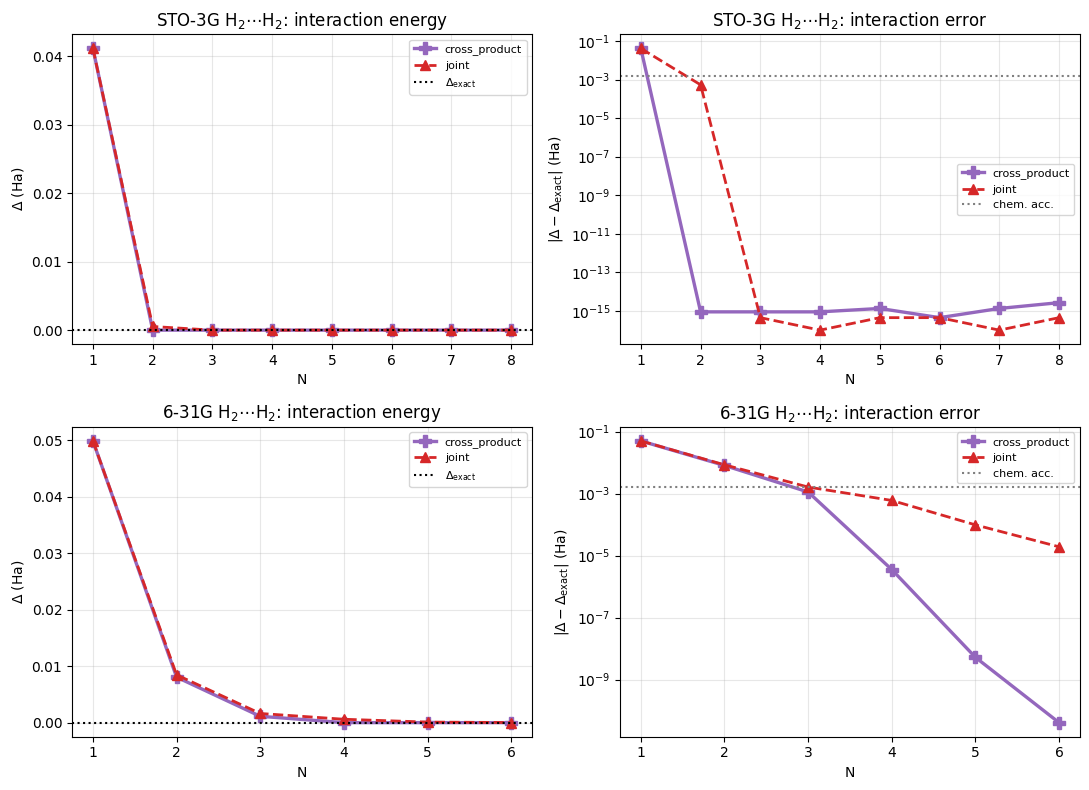

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h2_cross_product_interaction_vs_N__spectral_norm.png


In [6]:
fig, axes = plt.subplots(len(BASIS_LIST), 2, figsize=(11, 4.0 * len(BASIS_LIST)))
if len(BASIS_LIST) == 1:
    axes = np.array([axes])
for row, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h2[df_h2h2['basis'] == basis]
    ax = axes[row, 0]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h2[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_2$: interaction energy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_2$: interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
path = artifact_path('h2h2_cross_product_interaction_vs_N.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


### 8a. H$_2$⋯H$_2$ interaction via $E(R{=}1.1)-E(\mathrm{Kronecker})$

Real interacting dimer at $R=1.1$ Å (Parity-mapped, dressed $H_A$, $H_B$) vs the §8 Kronecker $E_{\mathrm{method}}(N)$ as the R→∞ reference:

$$
\Delta(N)=E_{\mathrm{method}}(R{=}1.1,\,N)-E_{\mathrm{method}}^{\mathrm{Kronecker}}(N),
\qquad
\Delta_{\mathrm{exact}}=E_{\mathrm{exact}}(1.1)-(E_A+E_B).
$$

Intramolecular bond matches Kronecker (`BOND=0.7414`). R=1.1 uses qubit mapping; Kronecker uses number-preserving Fock — absolute energies (Ha) are compared chemically.


In [7]:
# Real-dimer (R=1.1) helpers — Parity H2H2 / JW H2H4, dressed HA/HB for cross_product

def _pauli_support(label):
    n = len(label)
    return {n - 1 - j for j, ch in enumerate(label) if ch != 'I'}


def _exact_gs_electronic(H_dense=None, H_sp=None):
    if H_sp is not None:
        val, _ = eigsh(H_sp, k=1, which='SA')
        return float(val[0].real)
    return float(np.linalg.eigvalsh(H_dense)[0].real)


def _hf_ref(problem, mapper):
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    return np.array(Statevector(hf.decompose()).data, dtype=complex)


def partition_hamiltonian(H_op, qubits_a, qubits_b, use_sparse=False):
    qa, qb = set(qubits_a), set(qubits_b)
    pa, pb, pab, ca, cb, cab = [], [], [], [], [], []
    for pauli, coeff in zip(H_op.paulis, H_op.coeffs):
        label = pauli.to_label()
        sup = _pauli_support(label)
        c = complex(coeff)
        if sup <= qa:
            pa.append(label); ca.append(c)
        elif sup <= qb:
            pb.append(label); cb.append(c)
        else:
            pab.append(label); cab.append(c)

    def to_op(labels, coeffs):
        n = 2 ** H_op.num_qubits
        if not labels:
            return (csr_matrix((n, n), dtype=complex) if use_sparse
                    else np.zeros((n, n), dtype=complex))
        op = SparsePauliOp.from_list(list(zip(labels, coeffs)))
        return (op.to_matrix(sparse=True).tocsr() if use_sparse
                else op.to_matrix().astype(complex))

    H_a, H_b, H_ab = to_op(pa, ca), to_op(pb, cb), to_op(pab, cab)
    if use_sparse:
        H_tot = H_op.to_matrix(sparse=True).tocsr()
        residual = float(sparse_norm(H_tot - (H_a + H_b + H_ab), ord=2))
    else:
        H_tot = H_op.to_matrix().astype(complex)
        residual = float(np.linalg.norm(H_tot - H_a - H_b - H_ab, ord=2))
    return {'H_a': H_a, 'H_b': H_b, 'H_ab': H_ab, 'H_tot': H_tot, 'residual': residual}


def build_dressed(H_a, H_b, H_ab):
    return H_a + 0.5 * H_ab, H_b + 0.5 * H_ab


def _finalize_real_sys(dim, part, H_A, H_B, E_exact_sum, basis, system_tag):
    """Attach H_A_emb/H_B_emb aliases and DT_MODE dt for existing Krylov builders."""
    us = dim['use_sparse']
    H_elec = part['H_tot']
    e_min = e_max = None
    if us:
        e_min = _exact_gs_electronic(H_sp=H_elec)
        if DT_MODE == 'spectral_width':
            e_max = float(eigsh(H_elec, k=1, which='LA', return_eigenvectors=False)[0].real)
        dt = compute_dt(H_elec, e_min=e_min, e_max=e_max)
        dress_res = float(sparse_norm(H_elec - H_A - H_B, ord=2))
    else:
        ev = np.linalg.eigvalsh(H_elec)
        e_min, e_max = float(ev[0].real), float(ev[-1].real)
        dt = compute_dt(H_elec, e_min=e_min, e_max=e_max)
        dress_res = float(np.linalg.norm(H_A + H_B - H_elec, ord=2))

    gs_total = dim['gs_elec'] + dim['E_nuc']
    return {
        'H': None if us else H_elec,
        'H_sp': H_elec if us else None,
        'H_A_emb': H_A,
        'H_B_emb': H_B,
        'ref': dim['ref'],
        'joint_dim': dim['joint_dim'],
        'use_sparse': us,
        'gs_elec': dim['gs_elec'],
        'E_nuc': dim['E_nuc'],
        'gs_total': gs_total,
        'E_exact_sum': E_exact_sum,
        'delta_exact_vs_mono': gs_total - E_exact_sum,
        'dt_tot': dt,
        'dt_mode': DT_MODE,
        'dress_residual': dress_res,
        'basis': basis,
        'system': system_tag,
        'R': dim.get('R', dim.get('R_gap')),
        'n_qubits': dim['n_qubits'],
    }


def build_real_h2h2_system(basis, R=R_INT, bond=BOND):
    """Parity-mapped H2...H2 at finite R with dressed HA/HB (electronic H)."""
    b2 = bond / 2.0
    zA, zB = -R / 2.0, R / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H', 'H', 'H'],
        coords=[
            (0.0, 0.0, zA - b2), (0.0, 0.0, zA + b2),
            (0.0, 0.0, zB - b2), (0.0, 0.0, zB + b2),
        ],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > REAL_SPARSE_DIM_THRESHOLD
    H_sp = H_op.to_matrix(sparse=True).tocsr() if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = _exact_gs_electronic(H_dense=H, H_sp=H_sp)
    E_nuc = problem.nuclear_repulsion_energy
    n_q = H_op.num_qubits
    qa = list(range(n_q // 2))
    qb = list(range(n_q // 2, n_q))
    dim = {
        'H': H, 'H_op': H_op, 'H_sp': H_sp, 'ref': _hf_ref(problem, mapper),
        'E_nuc': E_nuc, 'n_qubits': n_q, 'joint_dim': joint_dim,
        'gs_elec': gs_elec, 'R': R, 'use_sparse': use_sparse, 'basis': basis,
    }
    part = partition_hamiltonian(H_op, qa, qb, use_sparse=use_sparse)
    H_A, H_B = build_dressed(part['H_a'], part['H_b'], part['H_ab'])
    E_sum = 2.0 * build_monomer(2, basis, bond=bond)['gs_total']
    return _finalize_real_sys(dim, part, H_A, H_B, E_sum, basis, 'H2+H2')


def _linear_h2_coords(z0=0.0, bond=BOND):
    return [(0.0, 0.0, z0), (0.0, 0.0, z0 + bond)]


def _linear_h4_coords(z0, bond=BOND):
    return [(0.0, 0.0, z0 + i * bond) for i in range(4)]


def build_real_h2h4_system(basis='sto-3g', R=R_INT, bond=BOND):
    """JW-mapped linear H2...H4 at finite R (STO-3G: 12 qubits)."""
    coords = _linear_h2_coords(0.0, bond) + _linear_h4_coords(bond + R, bond)
    mol = MoleculeInfo(
        symbols=['H'] * 6, coords=coords, charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = JordanWignerMapper()
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > REAL_SPARSE_DIM_THRESHOLD
    H_sp = H_op.to_matrix(sparse=True).tocsr() if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = _exact_gs_electronic(H_dense=H, H_sp=H_sp)
    E_nuc = problem.nuclear_repulsion_energy
    n_spatial = problem.num_spatial_orbitals
    assert n_spatial % 6 == 0, f'expected multiple of 6 spatial orbs, got {n_spatial}'
    n_ao_per_H = n_spatial // 6
    n_q_a = 2 * (2 * n_ao_per_H)
    n_q_b = 2 * (4 * n_ao_per_H)
    assert H_op.num_qubits == n_q_a + n_q_b
    qa = list(range(n_q_a))
    qb = list(range(n_q_a, n_q_a + n_q_b))
    dim = {
        'H': H, 'H_op': H_op, 'H_sp': H_sp, 'ref': _hf_ref(problem, mapper),
        'E_nuc': E_nuc, 'n_qubits': H_op.num_qubits, 'joint_dim': joint_dim,
        'gs_elec': gs_elec, 'R_gap': R, 'use_sparse': use_sparse, 'basis': basis,
    }
    part = partition_hamiltonian(H_op, qa, qb, use_sparse=use_sparse)
    H_A, H_B = build_dressed(part['H_a'], part['H_b'], part['H_ab'])
    E_sum = (build_monomer(2, basis, bond=bond)['gs_total']
             + build_monomer(4, basis, bond=bond)['gs_total'])
    return _finalize_real_sys(dim, part, H_A, H_B, E_sum, basis, 'H2+H4')


def energy_real_total(sys, states):
    """Gen-eig of electronic H, then add nuclear repulsion (total Ha)."""
    out = energy_from_states(sys, states)
    return {
        **out,
        'gs_elec': out['gs_total'],
        'gs_total': out['gs_total'] + sys['E_nuc'],
    }


print('Real-dimer R=1.1 helpers ready (H2H2 Parity, H2H4 JW).')


Real-dimer R=1.1 helpers ready (H2H2 Parity, H2H4 JW).


In [8]:
# §8a — H2...H2 at R=1.1 minus Kronecker E_method(N) from df_h2h2
h2h2_rdiff_rows = []
delta_exact_h2h2_rdiff = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§8a  H2...H2 R=1.1 vs Kronecker  ({label})')
    print('=' * 60)

    sys_11 = build_real_h2h2_system(basis, R=R_INT, bond=BOND)
    E_kron_exact = float(
        df_h2h2.loc[df_h2h2['basis'] == basis, 'gs_total'].iloc[0]
        - df_h2h2.loc[df_h2h2['basis'] == basis, 'delta'].iloc[0]
    )
    d_ex = sys_11['gs_total'] - E_kron_exact
    delta_exact_h2h2_rdiff[basis] = d_ex
    print(f"  dim={sys_11['joint_dim']}  sparse={sys_11['use_sparse']}  "
          f"dt={sys_11['dt_tot']:.4f}  dress_res={sys_11['dress_residual']:.2e}  "
          f"Delta_exact={d_ex:.6e}")
    assert abs(d_ex) > 1e-3, f'{basis}: expected nonzero interaction energy'

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in VARIANTS:
            out = energy_real_total(sys_11, VARIANT_BUILDERS[name](sys_11, N))
            E_kron = float(
                df_h2h2.loc[
                    (df_h2h2['basis'] == basis)
                    & (df_h2h2['variant'] == name)
                    & (df_h2h2['N'] == N),
                    'gs_total',
                ].iloc[0]
            )
            delta = out['gs_total'] - E_kron
            h2h2_rdiff_rows.append({
                'system': 'H2+H2', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'E_R11': out['gs_total'], 'E_kron': E_kron,
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta - d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del sys_11
    gc.collect()
    print()

df_h2h2_rdiff = pd.DataFrame(h2h2_rdiff_rows)
path_csv = artifact_path('h2h2_Rdiff_interaction_vs_N.csv')
df_h2h2_rdiff.to_csv(path_csv, index=False)
print('Saved:', path_csv)
print('\n=== §8a summary at N_max ===')
for basis in BASIS_LIST:
    sub = df_h2h2_rdiff[df_h2h2_rdiff['basis'] == basis]
    Nmax = int(sub['N'].max())
    print(f'{BASIS_CONFIG[basis]["label"]} N={Nmax}')
    print(sub.loc[sub['N'] == Nmax, ['variant', 'delta', 'delta_exact', 'err_int']].to_string(index=False))


§8a  H2...H2 R=1.1 vs Kronecker  (STO-3G)
  dim=64  sparse=False  dt=0.5452  dress_res=1.78e-15  Delta_exact=6.645655e-01
  N=1 ... cross_product(err=6.39e-03)  joint(err=6.39e-03)  
  N=2 ... cross_product(err=1.19e-02)  joint(err=1.90e-02)  
  N=3 ... cross_product(err=9.90e-04)  joint(err=6.91e-03)  
  N=4 ... cross_product(err=1.02e-04)  joint(err=1.51e-03)  
  N=5 ... cross_product(err=1.47e-13)  joint(err=5.78e-04)  
  N=6 ... cross_product(err=1.02e-14)  joint(err=1.48e-04)  
  N=7 ... cross_product(err=4.88e-15)  joint(err=6.54e-05)  
  N=8 ... cross_product(err=1.42e-14)  joint(err=3.80e-06)  

§8a  H2...H2 R=1.1 vs Kronecker  (6-31G)
  dim=16384  sparse=True  dt=0.0983  dress_res=2.13e-14  Delta_exact=5.408354e-01
  N=1 ... cross_product(err=1.06e-02)  joint(err=1.06e-02)  
  N=2 ... cross_product(err=5.46e-03)  joint(err=1.09e-02)  
  N=3 ... cross_product(err=4.07e-03)  joint(err=6.55e-03)  
  N=4 ... cross_product(err=1.85e-03)  joint(err=3.37e-03)  
  N=5 ... cross_produc

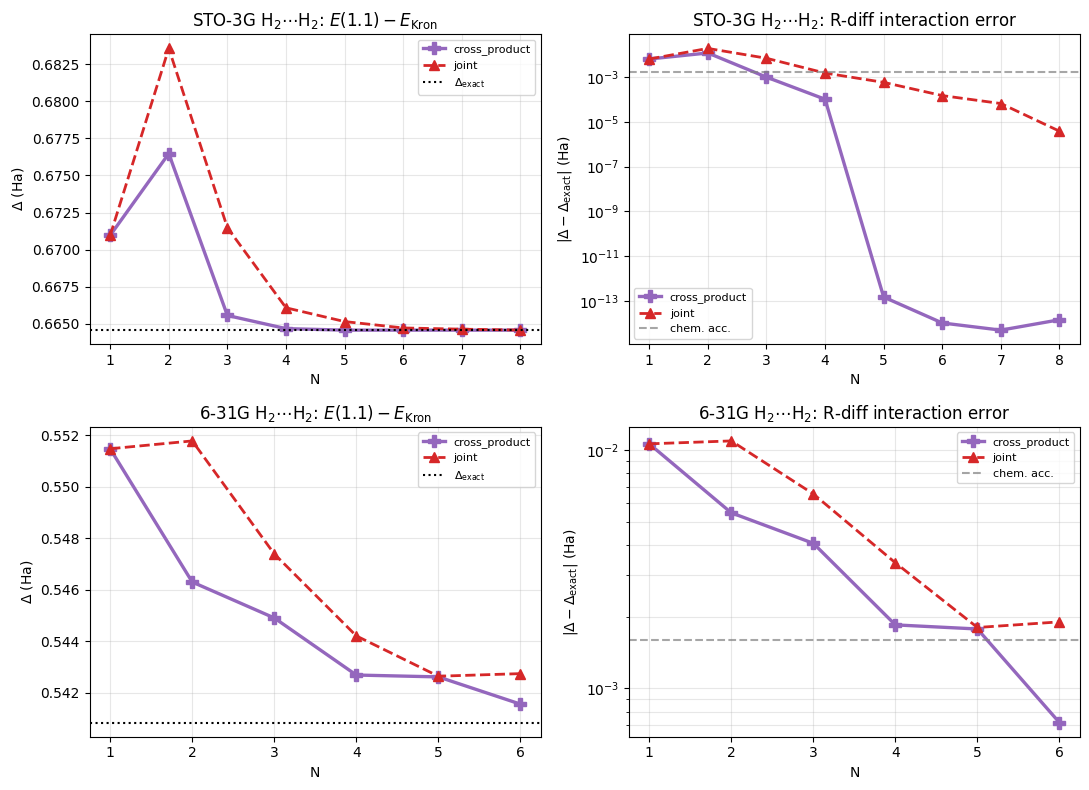

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h2_Rdiff_interaction_vs_N__spectral_norm.png


In [9]:
fig, axes = plt.subplots(len(BASIS_LIST), 2, figsize=(11, 4.0 * len(BASIS_LIST)))
if len(BASIS_LIST) == 1:
    axes = np.array([axes])

for i, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h2_rdiff[df_h2h2_rdiff['basis'] == basis]
    ax = axes[i, 0]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h2_rdiff[basis], color='k', ls=':',
               label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_2$: $E(1.1)-E_{{\mathrm{{Kron}}}}$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'],
                    ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls='--', alpha=0.7, label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_2$: R-diff interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
path = artifact_path('h2h2_Rdiff_interaction_vs_N.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


## 9. H$_2$⋯H$_4$ interaction energies — `cross_product` vs `joint`

System: $H=H_{\mathrm{H_2}}\otimes I+I\otimes H_{\mathrm{H_4}}$.

Same exponential bases as §8 with unequal fragments.

**Left:** $\Delta(N)=E_{\mathrm{method}}(N)-E_{\mathrm{exact}}(\mathrm{H_2})-E_{\mathrm{exact}}(\mathrm{H_4})$.

**Right:** $|\Delta(N)-\Delta_{\mathrm{exact}}|$ with $\Delta_{\mathrm{exact}}=0$.


In [10]:
h2h4_rows = []
delta_exact_h2h4 = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    # Cap H2+H4 6-31G Krylov N for cost on ~50k-dim space
    if basis == '6-31g':
        N_max = min(N_max, 4)
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§9  H2...H4  ({label})  N_max={N_max}')
    print('=' * 60)

    mono_a = build_monomer(2, basis)
    mono_b = build_monomer(4, basis)
    sys = build_kronecker_dimer(mono_a, mono_b)
    E_ref = sys['E_exact_sum']
    d_ex = sys['delta_exact']
    delta_exact_h2h4[basis] = d_ex
    print(f"  dims A/B={mono_a['dim']}/{mono_b['dim']}  dimer={sys['joint_dim']}  "
          f"sparse={sys['use_sparse']}  dt={sys['dt_tot']:.4f}  mode={sys['dt_mode']}  Delta_exact={d_ex:.3e}")

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in VARIANTS:
            out = energy_from_states(sys, VARIANT_BUILDERS[name](sys, N))
            delta = out['gs_total'] - E_ref
            h2h4_rows.append({
                'system': 'H2+H4', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - sys['gs_total']),
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta - d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del sys, mono_a, mono_b
    gc.collect()
    print()

df_h2h4 = pd.DataFrame(h2h4_rows)
path_csv = artifact_path('h2h4_cross_product_interaction_vs_N.csv')
df_h2h4.to_csv(path_csv, index=False)
print('Saved:', path_csv)


§9  H2...H4  (STO-3G)  N_max=8
  dims A/B=6/70  dimer=420  sparse=False  dt=0.9587  mode=spectral_norm  Delta_exact=1.021e-14
  N=1 ... cross_product(err=6.17e-02)  joint(err=6.17e-02)  
  N=2 ... cross_product(err=8.50e-03)  joint(err=1.01e-02)  
  N=3 ... cross_product(err=2.32e-03)  joint(err=2.59e-03)  
  N=4 ... cross_product(err=6.90e-04)  joint(err=9.51e-04)  
  N=5 ... cross_product(err=2.63e-04)  joint(err=3.93e-04)  
  N=6 ... cross_product(err=6.88e-05)  joint(err=1.21e-04)  
  N=7 ... cross_product(err=2.28e-05)  joint(err=6.59e-05)  
  N=8 ... cross_product(err=1.63e-06)  joint(err=4.00e-05)  

§9  H2...H4  (6-31G)  N_max=4
  dims A/B=28/1820  dimer=50960  sparse=True  dt=0.4735  mode=spectral_norm  Delta_exact=-1.910e-14
  N=1 ... cross_product(err=7.80e-02)  joint(err=7.80e-02)  
  N=2 ... cross_product(err=1.33e-02)  joint(err=1.42e-02)  
  N=3 ... cross_product(err=3.68e-03)  joint(err=4.69e-03)  
  N=4 ... cross_product(err=1.38e-03)  joint(err=1.86e-03)  

Saved: /ho

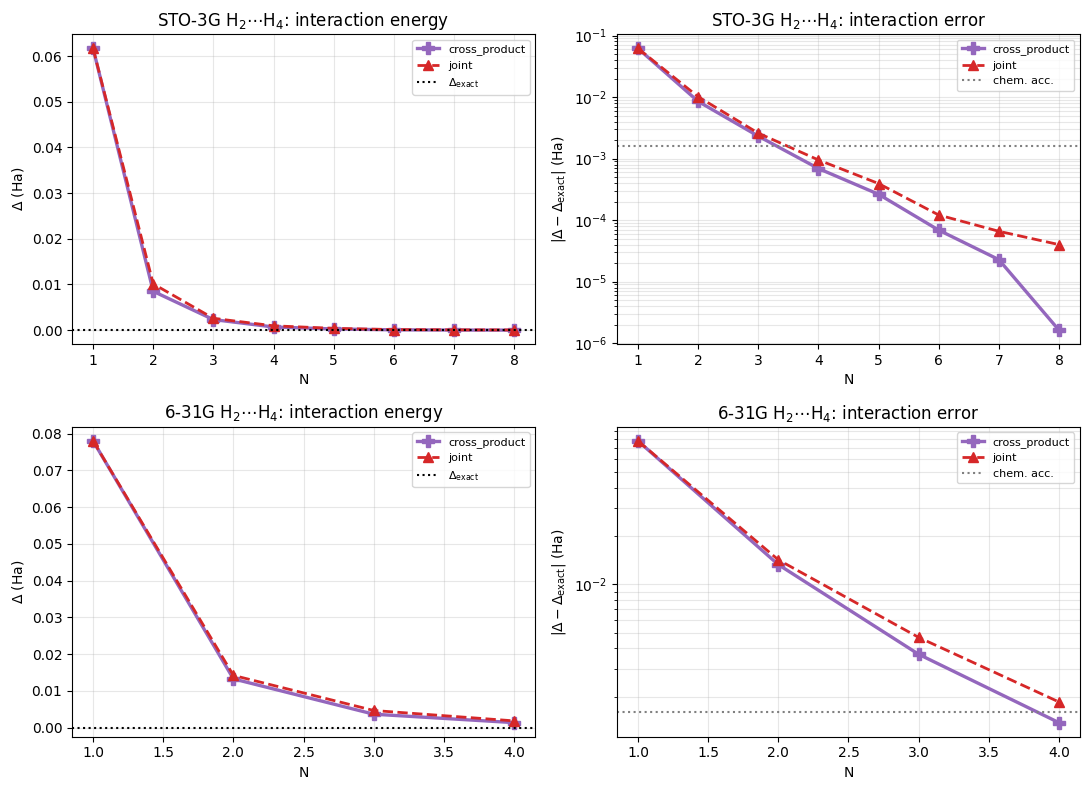

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h4_cross_product_interaction_vs_N__spectral_norm.png


In [11]:
plot_bases = [b for b in BASIS_LIST if b in delta_exact_h2h4]
fig, axes = plt.subplots(len(plot_bases), 2, figsize=(11, 4.0 * len(plot_bases)))
if len(plot_bases) == 1:
    axes = np.array([axes])
for row, basis in enumerate(plot_bases):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h4[df_h2h4['basis'] == basis]
    ax = axes[row, 0]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h4[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_4$: interaction energy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_4$: interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
path = artifact_path('h2h4_cross_product_interaction_vs_N.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


### 9a. H$_2$⋯H$_4$ interaction via $E(R{=}1.1)-E(\mathrm{Kronecker})$

Same definition as §8a for the linear hetero-dimer (STO-3G, full JW, 12 qubits). 6-31G is skipped (CAS vs NP Kronecker energies are not comparable).

$$
\Delta(N)=E_{\mathrm{method}}(R{=}1.1,\,N)-E_{\mathrm{method}}^{\mathrm{Kronecker}}(N).
$$


In [12]:
# §9a — H2...H4 STO-3G at R=1.1 minus Kronecker E_method(N) from df_h2h4
H2H4_RDIFF_BASIS = ['sto-3g']
h2h4_rdiff_rows = []
delta_exact_h2h4_rdiff = {}

for basis in H2H4_RDIFF_BASIS:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§9a  H2...H4 R=1.1 vs Kronecker  ({label})')
    print('=' * 60)

    sys_11 = build_real_h2h4_system(basis, R=R_INT, bond=BOND)
    E_kron_exact = float(
        df_h2h4.loc[df_h2h4['basis'] == basis, 'gs_total'].iloc[0]
        - df_h2h4.loc[df_h2h4['basis'] == basis, 'delta'].iloc[0]
    )
    d_ex = sys_11['gs_total'] - E_kron_exact
    delta_exact_h2h4_rdiff[basis] = d_ex
    print(f"  dim={sys_11['joint_dim']}  sparse={sys_11['use_sparse']}  "
          f"dt={sys_11['dt_tot']:.4f}  dress_res={sys_11['dress_residual']:.2e}  "
          f"Delta_exact={d_ex:.6e}")
    assert abs(d_ex) > 1e-4, f'{basis}: expected nonzero interaction energy'

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in VARIANTS:
            out = energy_real_total(sys_11, VARIANT_BUILDERS[name](sys_11, N))
            E_kron = float(
                df_h2h4.loc[
                    (df_h2h4['basis'] == basis)
                    & (df_h2h4['variant'] == name)
                    & (df_h2h4['N'] == N),
                    'gs_total',
                ].iloc[0]
            )
            delta = out['gs_total'] - E_kron
            h2h4_rdiff_rows.append({
                'system': 'H2+H4', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'E_R11': out['gs_total'], 'E_kron': E_kron,
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta - d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del sys_11
    gc.collect()
    print()

df_h2h4_rdiff = pd.DataFrame(h2h4_rdiff_rows)
path_csv = artifact_path('h2h4_Rdiff_interaction_vs_N.csv')
df_h2h4_rdiff.to_csv(path_csv, index=False)
print('Saved:', path_csv)
print('\n=== §9a summary at N_max ===')
for basis in H2H4_RDIFF_BASIS:
    sub = df_h2h4_rdiff[df_h2h4_rdiff['basis'] == basis]
    Nmax = int(sub['N'].max())
    print(f'{BASIS_CONFIG[basis]["label"]} N={Nmax}')
    print(sub.loc[sub['N'] == Nmax, ['variant', 'delta', 'delta_exact', 'err_int']].to_string(index=False))


§9a  H2...H4 R=1.1 vs Kronecker  (STO-3G)
  dim=4096  sparse=True  dt=0.3507  dress_res=7.22e-15  Delta_exact=3.865874e-02
  N=1 ... cross_product(err=4.57e-04)  joint(err=4.57e-04)  
  N=2 ... cross_product(err=5.67e-03)  joint(err=7.61e-04)  
  N=3 ... cross_product(err=1.77e-03)  joint(err=3.27e-04)  
  N=4 ... cross_product(err=5.97e-04)  joint(err=2.19e-04)  
  N=5 ... cross_product(err=2.40e-04)  joint(err=1.58e-04)  
  N=6 ... cross_product(err=5.52e-05)  joint(err=4.97e-05)  
  N=7 ... cross_product(err=1.84e-05)  joint(err=4.29e-05)  
  N=8 ... cross_product(err=8.02e-08)  joint(err=3.19e-05)  

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h4_Rdiff_interaction_vs_N__spectral_norm.csv

=== §9a summary at N_max ===
STO-3G N=8
      variant    delta  delta_exact      err_int
cross_product 0.038659     0.038659 8.017714e-08
        joint 0.038627     0.038659 3.185291e-05


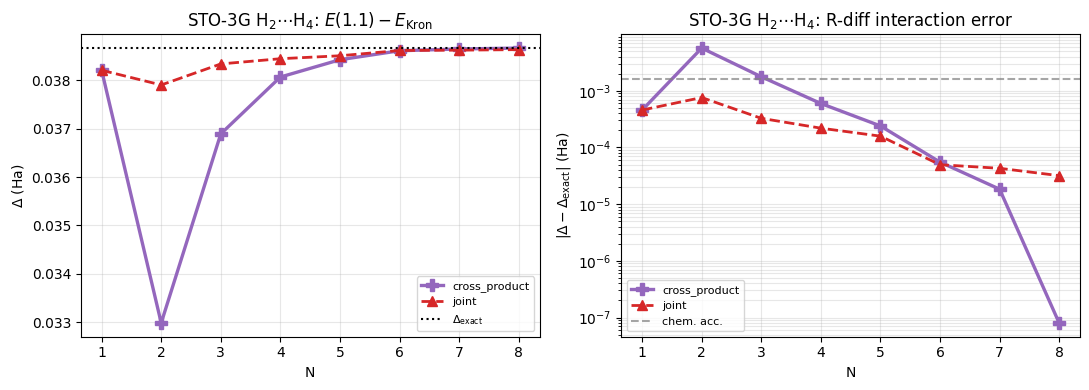

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h4_Rdiff_interaction_vs_N__spectral_norm.png


In [13]:
plot_bases = [b for b in H2H4_RDIFF_BASIS if b in delta_exact_h2h4_rdiff]
fig, axes = plt.subplots(len(plot_bases), 2, figsize=(11, 4.0 * len(plot_bases)))
if len(plot_bases) == 1:
    axes = np.array([axes])

for i, basis in enumerate(plot_bases):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h4_rdiff[df_h2h4_rdiff['basis'] == basis]
    ax = axes[i, 0]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h4_rdiff[basis], color='k', ls=':',
               label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_4$: $E(1.1)-E_{{\mathrm{{Kron}}}}$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'],
                    ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls='--', alpha=0.7, label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_4$: R-diff interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
path = artifact_path('h2h4_Rdiff_interaction_vs_N.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


### 8b / 9b. Size consistency (non-interacting / R=1000 limit)

Monomer QKD refs use the **same** $\Delta t$ as the dimer:

$$
|\phi^{A}_{k}\rangle=e^{-i H_A k\Delta t}|\mathrm{HF}_A\rangle,\qquad
|\phi^{B}_{k}\rangle=e^{-i H_B k\Delta t}|\mathrm{HF}_B\rangle.
$$

**Left:** $|\Delta_{\mathrm{SC}}(N)|=|E_{\mathrm{method}}(N)-E_A^{\mathrm{QKD}}(N)-E_B^{\mathrm{QKD}}(N)|$.

**Right:** $|E_{\mathrm{method}}(N)-E_{\mathrm{exact}}(H)|$ with $E_{\mathrm{exact}}(H)=E_{\mathrm{exact}}(H_A)+E_{\mathrm{exact}}(H_B)$.


In [14]:
SC_BASIS_LIST = list(BASIS_LIST)
# H2...H2: sto-3g converges by N~3; H2...H4 needs N~12 for H4 QKD (dim 70).
SC_N_MAX = {'sto-3g': {'H2+H2': 8, 'H2+H4': 12}, '6-31g': {'H2+H2': 8, 'H2+H4': 4}}
SC_ASSERT = 1e-10
# Right-column exact-dimer assert only when monomer QKD has reached exact GS.
MONO_ADEQUATE = 1e-9
sc_rows = []

print('=' * 60)
print('Size consistency — Kronecker R->inf / cross_product vs joint')
print('=' * 60)

for SC_BASIS in SC_BASIS_LIST:
    label = BASIS_CONFIG[SC_BASIS]['label']
    print()
    print('*' * 60)
    print(f'Basis: {label}')
    print('*' * 60)

    print(f"H2...H2 ({label}) N_max={SC_N_MAX[SC_BASIS]['H2+H2']} ...")
    mono = build_monomer(2, SC_BASIS)
    sys_hh = build_kronecker_dimer(mono, mono)
    E_ex = sys_hh['gs_total']
    SC_DIMS = list(range(1, SC_N_MAX[SC_BASIS]['H2+H2'] + 1))
    df_qkd = sweep_mono_qkd(mono, SC_DIMS, dt=sys_hh['dt_tot'])
    print(f"  E_exact={E_ex:.10f}  mono_dim={mono['dim']}")

    for N in SC_DIMS:
        print(f'  N={N} ...', end=' ', flush=True)
        E_sum = 2.0 * float(df_qkd.loc[df_qkd['N'] == N, 'E_mono_qkd'].iloc[0])
        for name in VARIANTS:
            out = energy_from_states(sys_hh, VARIANT_BUILDERS[name](sys_hh, N))
            d_mono = out['gs_total'] - E_sum
            d_dim = out['gs_total'] - E_ex
            sc_rows.append({
                'system': 'H2+H2', 'basis': SC_BASIS, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'], 'E_exact': E_ex,
                'E_mono_sum_qkd': E_sum,
                'delta_vs_mono': d_mono, 'delta_vs_dimer1000': d_dim,
            })
            print(f'{name}(D={d_mono:+.2e})', end='  ')
        print()
        gc.collect()
    del sys_hh, mono
    gc.collect()

    N_max_h4 = SC_N_MAX[SC_BASIS]['H2+H4']
    print(f'H2...H4 ({label}) N_max={N_max_h4} ...')
    SC_DIMS_H4 = list(range(1, N_max_h4 + 1))
    ma = build_monomer(2, SC_BASIS)
    mb = build_monomer(4, SC_BASIS)
    sys_h4 = build_kronecker_dimer(ma, mb)
    E_ex = sys_h4['gs_total']
    df_a = sweep_mono_qkd(ma, SC_DIMS_H4, dt=sys_h4['dt_tot'])
    df_b = sweep_mono_qkd(mb, SC_DIMS_H4, dt=sys_h4['dt_tot'])
    print(f"  E_exact={E_ex:.10f}  dims={ma['dim']}+{mb['dim']}->{sys_h4['joint_dim']}")

    for N in SC_DIMS_H4:
        print(f'  N={N} ...', end=' ', flush=True)
        E_sum = (
            float(df_a.loc[df_a['N'] == N, 'E_mono_qkd'].iloc[0])
            + float(df_b.loc[df_b['N'] == N, 'E_mono_qkd'].iloc[0])
        )
        for name in VARIANTS:
            out = energy_from_states(sys_h4, VARIANT_BUILDERS[name](sys_h4, N))
            d_mono = out['gs_total'] - E_sum
            d_dim = out['gs_total'] - E_ex
            sc_rows.append({
                'system': 'H2+H4', 'basis': SC_BASIS, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'], 'E_exact': E_ex,
                'E_mono_sum_qkd': E_sum,
                'delta_vs_mono': d_mono, 'delta_vs_dimer1000': d_dim,
            })
            print(f'{name}(D={d_mono:+.2e})', end='  ')
        print()
        gc.collect()
    del sys_h4, ma, mb
    gc.collect()

df_sc = pd.DataFrame(sc_rows)
df_sc['abs_vs_mono'] = np.abs(df_sc['delta_vs_mono'])
df_sc['abs_vs_dimer1000'] = np.abs(df_sc['delta_vs_dimer1000'])
path_csv = artifact_path('sc_R1000_cross_product.csv')
df_sc.to_csv(path_csv, index=False)
print('\nSaved:', path_csv)

print('\n=== SC at N_max ===')
for basis in SC_BASIS_LIST:
    sub_b = df_sc[df_sc['basis'] == basis]
    print(f"--- {BASIS_CONFIG[basis]['label']} ---")
    for system in ['H2+H2', 'H2+H4']:
        sub_s = sub_b[sub_b['system'] == system]
        if len(sub_s) == 0:
            continue
        N_show = int(sub_s['N'].max())
        sub = sub_s[sub_s['N'] == N_show]
        print(f'  {system} at N={N_show}:')
        print(sub[['variant', 'abs_vs_mono', 'abs_vs_dimer1000']].to_string(
            index=False, float_format=lambda x: f'{x:.4e}'))

print('\n=== SC asserts (cross_product) ===')
# When S is rank-deficient (eff_dim < raw_dim), gen-eig residuals sit near the
# SVD floor — looser than machine epsilon (seen with spectral_width on large dimers).
SC_ASSERT_RANK_DEF = 1e-5
for basis in SC_BASIS_LIST:
    for system in ['H2+H2', 'H2+H4']:
        sub = df_sc[(df_sc['basis'] == basis) & (df_sc['system'] == system)
                    & (df_sc['variant'] == 'cross_product')]
        if len(sub) == 0:
            continue
        r = sub.loc[sub['N'].idxmax()]
        mono_gap = abs(r['E_mono_sum_qkd'] - r['E_exact'])
        rank_def = int(r['eff_dim']) < int(r['raw_dim'])
        tol = SC_ASSERT_RANK_DEF if rank_def else SC_ASSERT
        print(f"{BASIS_CONFIG[basis]['label']} {system}: "
              f"|d_mono|={r['abs_vs_mono']:.3e}  |d_dim|={r['abs_vs_dimer1000']:.3e}  "
              f"mono_gap={mono_gap:.3e}  eff={int(r['eff_dim'])}/{int(r['raw_dim'])}  "
              f"tol={tol:.0e}")
        assert r['abs_vs_mono'] < tol, (
            f'{basis} {system} abs_vs_mono={r["abs_vs_mono"]} (tol={tol})')
        if mono_gap < MONO_ADEQUATE:
            assert r['abs_vs_dimer1000'] < tol, (
                f'{basis} {system} abs_vs_dimer={r["abs_vs_dimer1000"]} (tol={tol})')
        else:
            print(f'  (skip |d_dim| assert: monomer Krylov not yet adequate)')
print('SC asserts passed.')


Size consistency — Kronecker R->inf / cross_product vs joint

************************************************************
Basis: STO-3G
************************************************************
H2...H2 (STO-3G) N_max=8 ...
  E_exact=-2.2745403493  mono_dim=6
  N=1 ... cross_product(D=+0.00e+00)  joint(D=+0.00e+00)  
  N=2 ... cross_product(D=-8.88e-16)  joint(D=+5.32e-04)  
  N=3 ... cross_product(D=+0.00e+00)  joint(D=-4.44e-16)  
  N=4 ... cross_product(D=-8.88e-16)  joint(D=-1.78e-15)  
  N=5 ... cross_product(D=-2.66e-15)  joint(D=-8.88e-16)  
  N=6 ... cross_product(D=+4.44e-16)  joint(D=-4.44e-16)  
  N=7 ... cross_product(D=-1.33e-15)  joint(D=+0.00e+00)  
  N=8 ... cross_product(D=+1.78e-15)  joint(D=-4.44e-16)  
H2...H4 (STO-3G) N_max=12 ...
  E_exact=-3.2770698194  dims=6+70->420
  N=1 ... cross_product(D=+0.00e+00)  joint(D=+0.00e+00)  
  N=2 ... 

cross_product(D=-1.33e-15)  joint(D=+1.63e-03)  
  N=3 ... cross_product(D=+2.66e-15)  joint(D=+2.75e-04)  
  N=4 ... cross_product(D=+4.88e-15)  joint(D=+2.61e-04)  
  N=5 ... cross_product(D=-8.88e-16)  joint(D=+1.30e-04)  
  N=6 ... cross_product(D=-8.88e-16)  joint(D=+5.24e-05)  
  N=7 ... cross_product(D=+2.66e-15)  joint(D=+4.30e-05)  
  N=8 ... cross_product(D=-1.78e-15)  joint(D=+3.84e-05)  
  N=9 ... cross_product(D=-2.22e-15)  joint(D=+1.73e-05)  
  N=10 ... cross_product(D=-4.88e-15)  joint(D=+1.23e-05)  
  N=11 ... cross_product(D=-1.33e-15)  joint(D=+9.28e-06)  
  N=12 ... cross_product(D=-8.88e-16)  joint(D=+5.28e-06)  

************************************************************
Basis: 6-31G
************************************************************
H2...H2 (6-31G) N_max=8 ...
  E_exact=-2.3033654642  mono_dim=28
  N=1 ... cross_product(D=+0.00e+00)  joint(D=+0.00e+00)  
  N=2 ... cross_product(D=-4.44e-16)  joint(D=+4.05e-04)  
  N=3 ... cross_product(D=-4.44e-16)  j

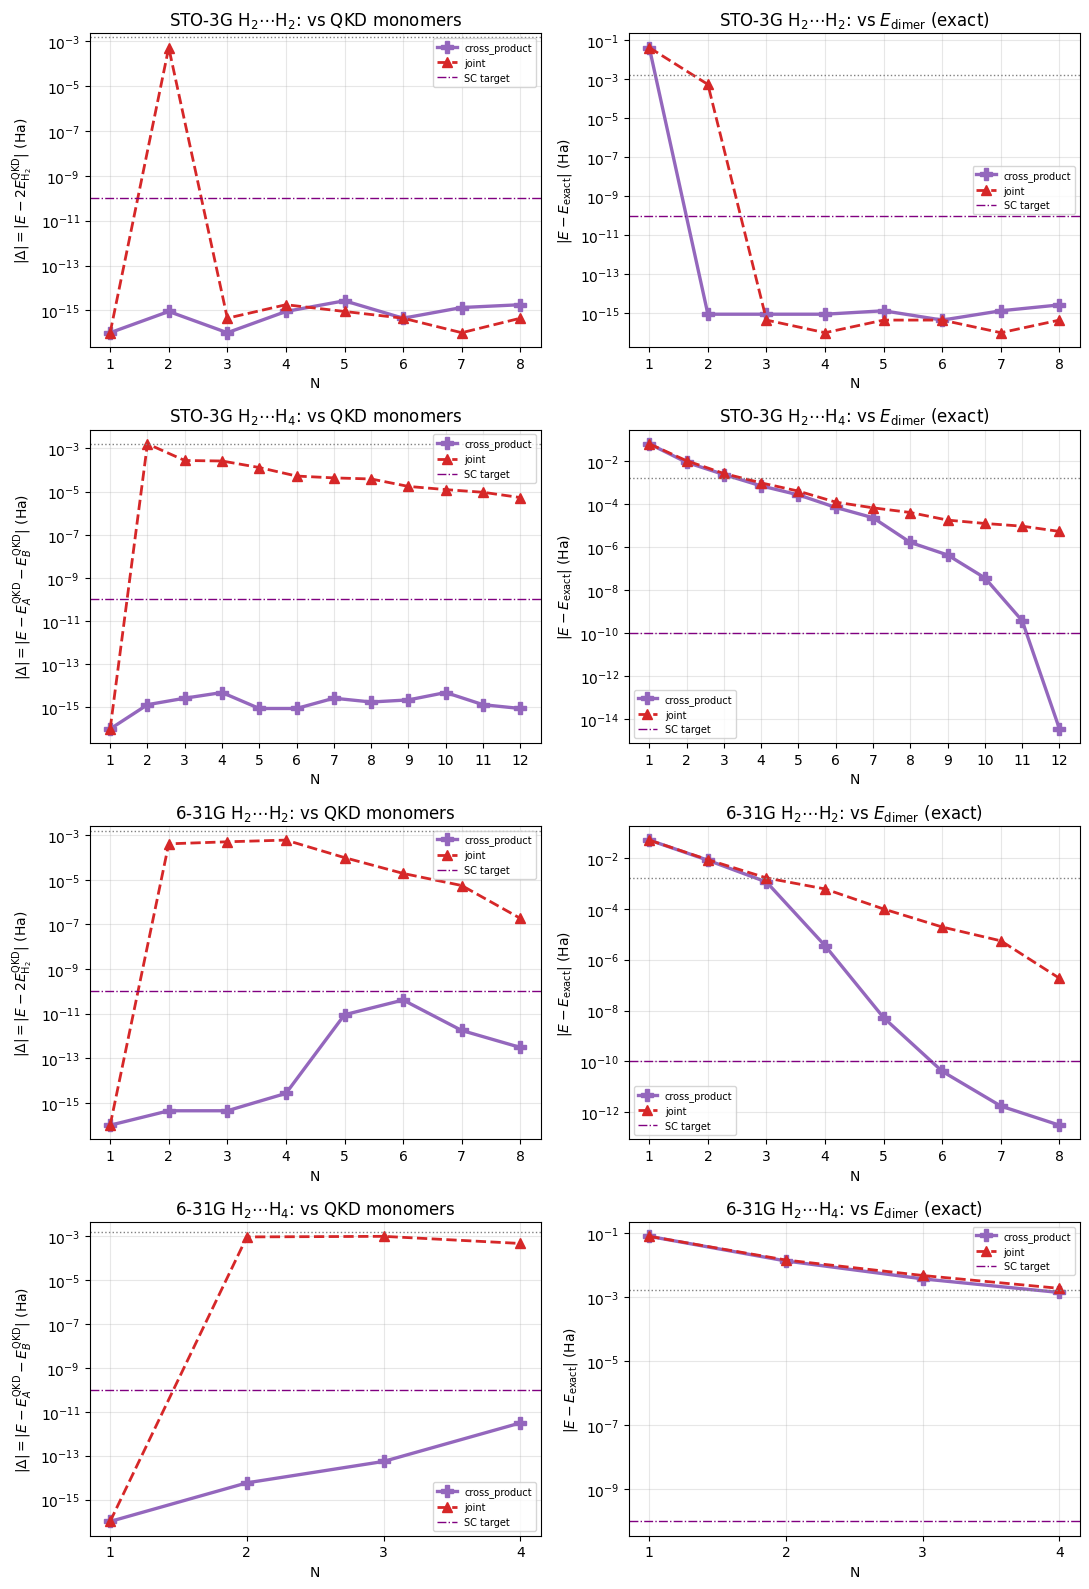

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/sc_R1000_cross_product__spectral_norm.png


In [15]:
n_basis = len(SC_BASIS_LIST)
fig, axes = plt.subplots(n_basis * 2, 2, figsize=(11, 4.0 * n_basis * 2))
if n_basis == 1:
    axes = np.array([axes])

panel = [
    ('H2+H2', r'H$_2\cdots$H$_2$',
     r'$|\Delta|=|E-2E_{\mathrm{H_2}}^{\mathrm{QKD}}|$'),
    ('H2+H4', r'H$_2\cdots$H$_4$',
     r'$|\Delta|=|E-E_A^{\mathrm{QKD}}-E_B^{\mathrm{QKD}}|$'),
]
for b_idx, basis in enumerate(SC_BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    for s_idx, (system, sys_label, ylab) in enumerate(panel):
        row = b_idx * 2 + s_idx
        sub_sys = df_sc[(df_sc['system'] == system) & (df_sc['basis'] == basis)]
        for col, (key, title_ref) in enumerate([
            ('abs_vs_mono', 'QKD monomers'),
            ('abs_vs_dimer1000', r'$E_{\mathrm{dimer}}$ (exact)'),
        ]):
            ax = axes[row, col]
            for name in VARIANTS:
                s = sub_sys[sub_sys['variant'] == name]
                if len(s) == 0:
                    continue
                st = VARIANT_STYLE[name]
                ax.semilogy(s['N'], np.maximum(s[key], 1e-16),
                            color=st['color'], marker=st['marker'], ls=st['ls'],
                            lw=st['lw'], ms=st['ms'], label=name)
            ax.axhline(CHEM_ACC, color='gray', ls=':', lw=1)
            ax.axhline(SC_ASSERT, color='purple', ls='-.', lw=1, label='SC target')
            ax.set_xlabel('N')
            ax.set_ylabel((ylab if col == 0 else r'$|E-E_{\mathrm{exact}}|$') + ' (Ha)')
            ax.set_title(rf'{label} {sys_label}: vs {title_ref}')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3, which='both')
            if len(sub_sys):
                ax.set_xticks(sorted(sub_sys['N'].unique()))
fig.tight_layout()
path = artifact_path('sc_R1000_cross_product.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


### 8c. SC residual vs Krylov effective dimension

Large-$N$ lift-off of $|\Delta_{\mathrm{SC}}|$ tracks SVD truncation of a singular overlap $S$, not a physical loss of size consistency.

**Left — size-consistency residual** (same as §8b left column):

$$
|\Delta_{\mathrm{SC}}(N)|
=
\bigl|
E_{\mathrm{method}}(N)
-
E_A^{\mathrm{QKD}}(N)
-
E_B^{\mathrm{QKD}}(N)
\bigr|
$$

with $E_A^{\mathrm{QKD}}=E_B^{\mathrm{QKD}}$ for H$_2\cdots$H$_2$. $E_{\mathrm{method}}$ is the lowest generalized eigenvalue of $H$ in the method’s exponential span (`cross_product` or `joint`).

**Right — effective Krylov dimension**, from the projected overlap of Krylov states $\{|v_a\rangle\}$:

$$
S_{ab}=\langle v_a|v_b\rangle,
\qquad
S\,u_i=\sigma_i\,u_i,
\qquad
\mathrm{eff\_dim}
=
\#\{\,i:\sigma_i>\tau\,\},
\qquad
\tau=10^{-10}.
$$

$\mathrm{raw\_dim}$ is the number of states before truncation ($N$ for `joint`, $N^2$ for `cross_product`). When $\mathrm{eff\_dim}<\mathrm{raw\_dim}$, $S$ is numerically singular and the gen-eig residual floor rises toward $\tau$.


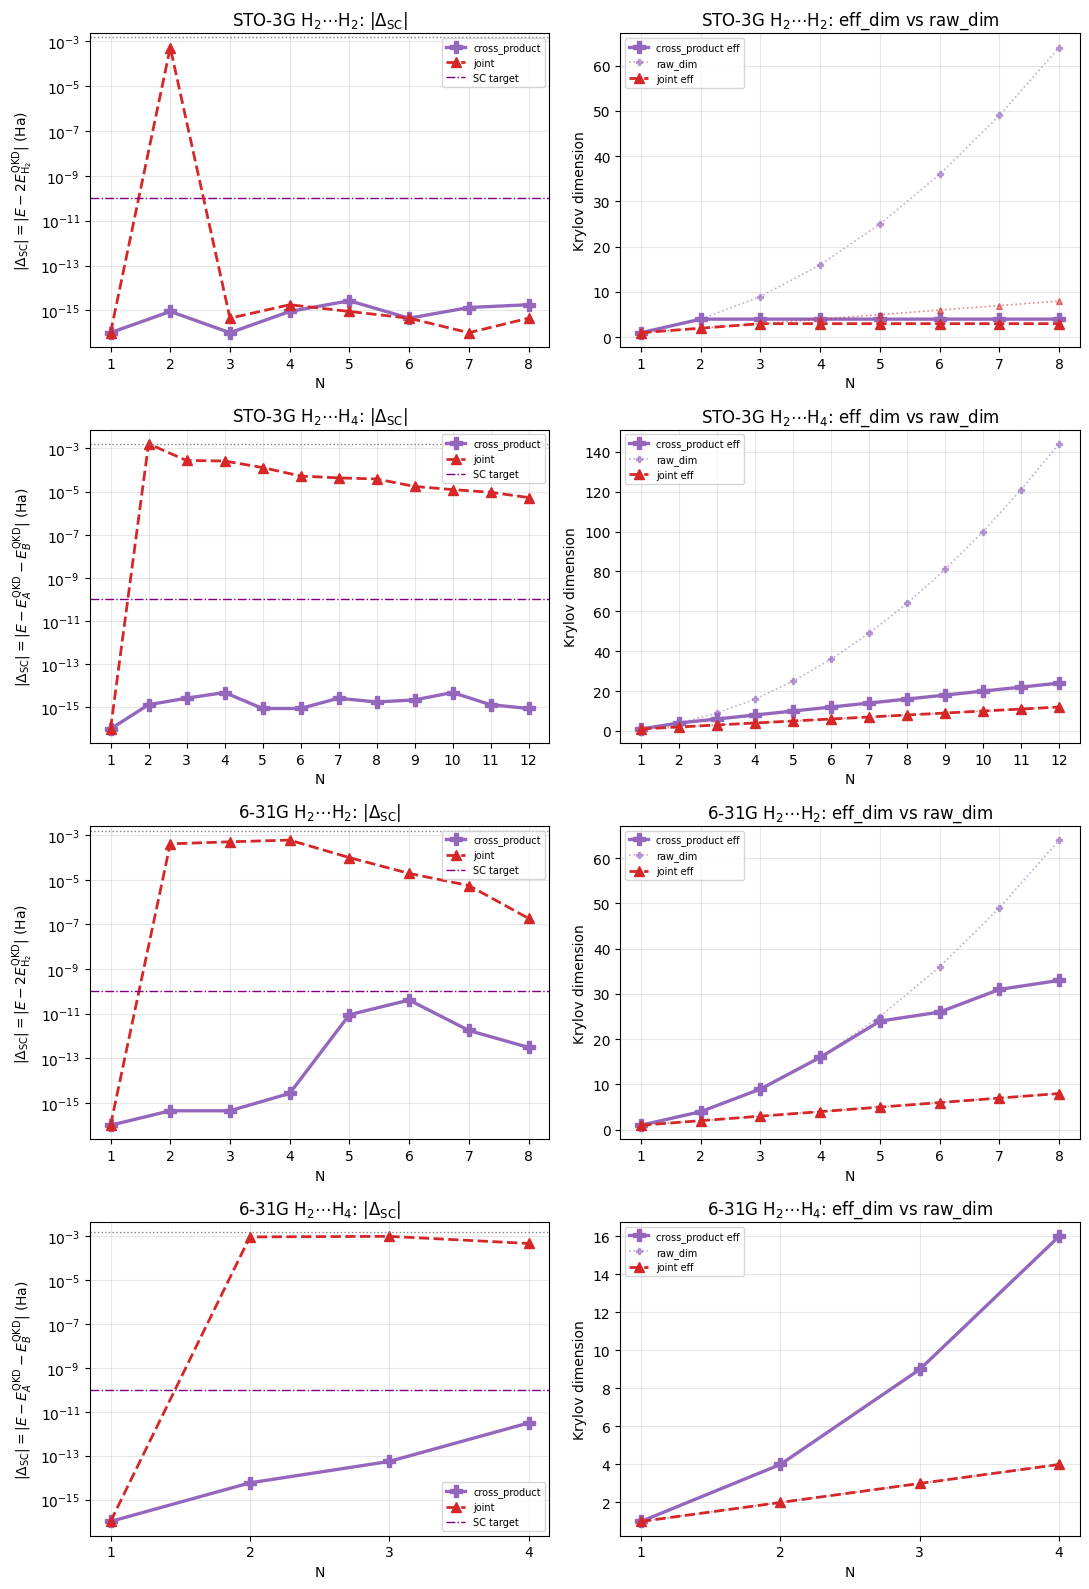

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/sc_effdim_diagnostic__spectral_norm.png


In [16]:
# §8c diagnostic: |Δ_SC| vs eff_dim (reuse df_sc; no new sweeps)
n_basis = len(SC_BASIS_LIST)
fig, axes = plt.subplots(n_basis * 2, 2, figsize=(11, 4.0 * n_basis * 2))
if n_basis == 1:
    axes = np.array([axes])

panel = [
    ('H2+H2', r'H$_2\cdots$H$_2$',
     r'$|\Delta_{\mathrm{SC}}|=|E-2E_{\mathrm{H_2}}^{\mathrm{QKD}}|$'),
    ('H2+H4', r'H$_2\cdots$H$_4$',
     r'$|\Delta_{\mathrm{SC}}|=|E-E_A^{\mathrm{QKD}}-E_B^{\mathrm{QKD}}|$'),
]
for b_idx, basis in enumerate(SC_BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    for s_idx, (system, sys_label, ylab) in enumerate(panel):
        row = b_idx * 2 + s_idx
        sub_sys = df_sc[(df_sc['system'] == system) & (df_sc['basis'] == basis)]
        # Left: |Δ_SC|
        ax = axes[row, 0]
        for name in VARIANTS:
            s = sub_sys[sub_sys['variant'] == name]
            if len(s) == 0:
                continue
            st = VARIANT_STYLE[name]
            ax.semilogy(s['N'], np.maximum(s['abs_vs_mono'], 1e-16),
                        color=st['color'], marker=st['marker'], ls=st['ls'],
                        lw=st['lw'], ms=st['ms'], label=name)
        ax.axhline(CHEM_ACC, color='gray', ls=':', lw=1)
        ax.axhline(SC_ASSERT, color='purple', ls='-.', lw=1, label='SC target')
        ax.set_xlabel('N')
        ax.set_ylabel(ylab + ' (Ha)')
        ax.set_title(rf'{label} {sys_label}: $|\Delta_{{\mathrm{{SC}}}}|$')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, which='both')
        if len(sub_sys):
            ax.set_xticks(sorted(sub_sys['N'].unique()))

        # Right: eff_dim (+ raw_dim reference)
        ax = axes[row, 1]
        raw_drawn = False
        for name in VARIANTS:
            s = sub_sys[sub_sys['variant'] == name].sort_values('N')
            if len(s) == 0:
                continue
            st = VARIANT_STYLE[name]
            ax.plot(s['N'], s['eff_dim'],
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=f'{name} eff')
            ax.plot(s['N'], s['raw_dim'],
                    color=st['color'], marker=st['marker'], ls=':',
                    lw=1.2, ms=5, alpha=0.55,
                    label=('raw_dim' if not raw_drawn else None))
            raw_drawn = True
        ax.set_xlabel('N')
        ax.set_ylabel(r'Krylov dimension')
        ax.set_title(rf'{label} {sys_label}: eff_dim vs raw_dim')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        if len(sub_sys):
            ax.set_xticks(sorted(sub_sys['N'].unique()))

fig.tight_layout()
path = artifact_path('sc_effdim_diagnostic.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


## 10. Cross-product Lanczos ($N^2$) — SC and rank diagnostics

Replace length-$N$ Lanczos-on-$H$ with the **cross-product structure** at size $N^2$: orthonormal monomer Lanczos chains tensored together,

$$
|\Psi_{kl}\rangle
=
|\phi^{A}_{k}\rangle\otimes|\phi^{B}_{l}\rangle,
\qquad
k,l=0,\ldots,N'-1,
$$

where $\{|\phi^{A}_{k}\rangle\}$ / $\{|\phi^{B}_{l}\rangle\}$ are length-$N$ Lanczos chains on $H_A$, $H_B$. Early $\beta$-break may give $N'<N$ per fragment ($\mathrm{raw\_dim}=N_A'N_B'$).

Because the fragment bases are orthonormal, $S\approx I$ on the product set ($\mathrm{dropped}\approx 0$). Because $H=H_A\otimes I+I\otimes H_B$, the variational energy factors $\Rightarrow$ size-consistent like exponential `cross_product`.

**SC (method-matched monomers):**

- `cross_product` / `joint`: $|\Delta_{\mathrm{SC}}|=|E-E_A^{\mathrm{QKD}}-E_B^{\mathrm{QKD}}|$ (shared $\Delta t$)
- `cp_lanczos`: $|\Delta_{\mathrm{SC}}|=|E-E_A^{\mathrm{Lanczos}}-E_B^{\mathrm{Lanczos}}|$ at the same $N$

Right column: $|E-E_{\mathrm{exact}}|$ with $E_{\mathrm{exact}}=E_A^{\mathrm{exact}}+E_B^{\mathrm{exact}}$.


In [17]:
# §10 — SC + rank metrics including N^2 cp_lanczos
lanczos_rows = []

print('=' * 60)
print('§10 Size consistency — cross_product / joint / cp_lanczos')
print('=' * 60)

for SC_BASIS in SC_BASIS_LIST:
    label = BASIS_CONFIG[SC_BASIS]['label']
    print()
    print('*' * 60)
    print(f'Basis: {label}')
    print('*' * 60)

    print(f"H2...H2 ({label}) N_max={SC_N_MAX[SC_BASIS]['H2+H2']} ...")
    mono = build_monomer(2, SC_BASIS)
    sys_hh = build_kronecker_dimer(mono, mono)
    E_ex = sys_hh['gs_total']
    SC_DIMS = list(range(1, SC_N_MAX[SC_BASIS]['H2+H2'] + 1))
    df_qkd = sweep_mono_qkd(mono, SC_DIMS, dt=sys_hh['dt_tot'])
    print(f"  E_exact={E_ex:.10f}  mono_dim={mono['dim']}")

    for N in SC_DIMS:
        print(f'  N={N} ...', end=' ', flush=True)
        E_qkd = 2.0 * float(df_qkd.loc[df_qkd['N'] == N, 'E_mono_qkd'].iloc[0])
        E_lz, _, _ = energy_from_mono_lanczos(mono, N)
        E_lz_sum = 2.0 * E_lz
        for name in LANCZOS_VARIANTS:
            out = energy_from_states(sys_hh, VARIANT_BUILDERS[name](sys_hh, N))
            E_sum = E_lz_sum if name == 'cp_lanczos' else E_qkd
            d_mono = out['gs_total'] - E_sum
            d_dim = out['gs_total'] - E_ex
            lanczos_rows.append({
                'system': 'H2+H2', 'basis': SC_BASIS, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'], 'E_exact': E_ex,
                'E_mono_sum_ref': E_sum,
                'delta_vs_mono': d_mono, 'delta_vs_dimer1000': d_dim,
            })
            print(f'{name}(D={d_mono:+.2e},eff={out["eff_dim"]}/{out["raw_dim"]})',
                  end='  ')
        print()
        gc.collect()
    del sys_hh, mono
    gc.collect()

    N_max_h4 = SC_N_MAX[SC_BASIS]['H2+H4']
    print(f'H2...H4 ({label}) N_max={N_max_h4} ...')
    SC_DIMS_H4 = list(range(1, N_max_h4 + 1))
    ma = build_monomer(2, SC_BASIS)
    mb = build_monomer(4, SC_BASIS)
    sys_h4 = build_kronecker_dimer(ma, mb)
    E_ex = sys_h4['gs_total']
    df_a = sweep_mono_qkd(ma, SC_DIMS_H4, dt=sys_h4['dt_tot'])
    df_b = sweep_mono_qkd(mb, SC_DIMS_H4, dt=sys_h4['dt_tot'])
    print(f"  E_exact={E_ex:.10f}  dims={ma['dim']}+{mb['dim']}->{sys_h4['joint_dim']}")

    for N in SC_DIMS_H4:
        print(f'  N={N} ...', end=' ', flush=True)
        E_qkd = (
            float(df_a.loc[df_a['N'] == N, 'E_mono_qkd'].iloc[0])
            + float(df_b.loc[df_b['N'] == N, 'E_mono_qkd'].iloc[0])
        )
        Ea_lz, _, _ = energy_from_mono_lanczos(ma, N)
        Eb_lz, _, _ = energy_from_mono_lanczos(mb, N)
        E_lz_sum = Ea_lz + Eb_lz
        for name in LANCZOS_VARIANTS:
            out = energy_from_states(sys_h4, VARIANT_BUILDERS[name](sys_h4, N))
            E_sum = E_lz_sum if name == 'cp_lanczos' else E_qkd
            d_mono = out['gs_total'] - E_sum
            d_dim = out['gs_total'] - E_ex
            lanczos_rows.append({
                'system': 'H2+H4', 'basis': SC_BASIS, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'], 'E_exact': E_ex,
                'E_mono_sum_ref': E_sum,
                'delta_vs_mono': d_mono, 'delta_vs_dimer1000': d_dim,
            })
            print(f'{name}(D={d_mono:+.2e},eff={out["eff_dim"]}/{out["raw_dim"]})',
                  end='  ')
        print()
        gc.collect()
    del sys_h4, ma, mb
    gc.collect()

df_sc_lanczos = pd.DataFrame(lanczos_rows)
df_sc_lanczos['abs_vs_mono'] = np.abs(df_sc_lanczos['delta_vs_mono'])
df_sc_lanczos['abs_vs_dimer1000'] = np.abs(df_sc_lanczos['delta_vs_dimer1000'])
df_sc_lanczos['dropped'] = df_sc_lanczos['raw_dim'] - df_sc_lanczos['eff_dim']
path_csv = artifact_path('sc_R1000_with_lanczos.csv')
df_sc_lanczos.to_csv(path_csv, index=False)
print('\nSaved:', path_csv)

print('\n=== §10 summary at N_max ===')
for basis in SC_BASIS_LIST:
    sub_b = df_sc_lanczos[df_sc_lanczos['basis'] == basis]
    print(f"--- {BASIS_CONFIG[basis]['label']} ---")
    for system in ['H2+H2', 'H2+H4']:
        sub_s = sub_b[sub_b['system'] == system]
        if len(sub_s) == 0:
            continue
        N_show = int(sub_s['N'].max())
        sub = sub_s[sub_s['N'] == N_show]
        print(f'  {system} at N={N_show}:')
        print(sub[['variant', 'abs_vs_mono', 'abs_vs_dimer1000', 'eff_dim', 'raw_dim', 'dropped']].to_string(
            index=False, float_format=lambda x: f'{x:.4e}'))


§10 Size consistency — cross_product / joint / cp_lanczos

************************************************************
Basis: STO-3G
************************************************************
H2...H2 (STO-3G) N_max=8 ...
  E_exact=-2.2745403493  mono_dim=6
  N=1 ... cross_product(D=+0.00e+00,eff=1/1)  joint(D=+0.00e+00,eff=1/1)  cp_lanczos(D=+0.00e+00,eff=1/1)  
  N=2 ... cross_product(D=-8.88e-16,eff=4/4)  joint(D=+5.32e-04,eff=2/2)  cp_lanczos(D=+0.00e+00,eff=4/4)  
  N=3 ... cross_product(D=+0.00e+00,eff=4/9)  joint(D=-4.44e-16,eff=3/3)  cp_lanczos(D=+0.00e+00,eff=4/4)  
  N=4 ... cross_product(D=-8.88e-16,eff=4/16)  joint(D=-1.78e-15,eff=3/4)  cp_lanczos(D=+0.00e+00,eff=4/4)  
  N=5 ... cross_product(D=-2.66e-15,eff=4/25)  joint(D=-8.88e-16,eff=3/5)  cp_lanczos(D=+0.00e+00,eff=4/4)  
  N=6 ... cross_product(D=+4.44e-16,eff=4/36)  joint(D=-4.44e-16,eff=3/6)  cp_lanczos(D=+0.00e+00,eff=4/4)  
  N=7 ... cross_product(D=-1.33e-15,eff=4/49)  joint(D=+0.00e+00,eff=3/7)  cp_lanczos(D=+

cross_product(D=+1.33e-15,eff=8/16)  joint(D=+2.61e-04,eff=4/4)  cp_lanczos(D=+1.33e-15,eff=8/8)  
  N=5 ... cross_product(D=-5.77e-15,eff=10/25)  joint(D=+1.30e-04,eff=5/5)  cp_lanczos(D=+4.44e-16,eff=10/10)  
  N=6 ... cross_product(D=-2.22e-15,eff=12/36)  joint(D=+5.24e-05,eff=6/6)  cp_lanczos(D=+2.22e-15,eff=12/12)  
  N=7 ... cross_product(D=-4.44e-16,eff=14/49)  joint(D=+4.30e-05,eff=7/7)  cp_lanczos(D=+1.78e-15,eff=14/14)  
  N=8 ... cross_product(D=-8.88e-16,eff=16/64)  joint(D=+3.84e-05,eff=8/8)  cp_lanczos(D=-4.44e-15,eff=16/16)  
  N=9 ... cross_product(D=-5.77e-15,eff=18/81)  joint(D=+1.73e-05,eff=9/9)  cp_lanczos(D=+4.44e-16,eff=18/18)  
  N=10 ... cross_product(D=-7.55e-15,eff=20/100)  joint(D=+1.23e-05,eff=10/10)  cp_lanczos(D=+8.88e-16,eff=20/20)  
  N=11 ... cross_product(D=+4.44e-16,eff=22/121)  joint(D=+9.28e-06,eff=11/11)  cp_lanczos(D=+6.22e-15,eff=22/22)  
  N=12 ... cross_product(D=-8.88e-16,eff=24/144)  joint(D=+5.28e-06,eff=12/12)  cp_lanczos(D=+8.88e-16,eff=24

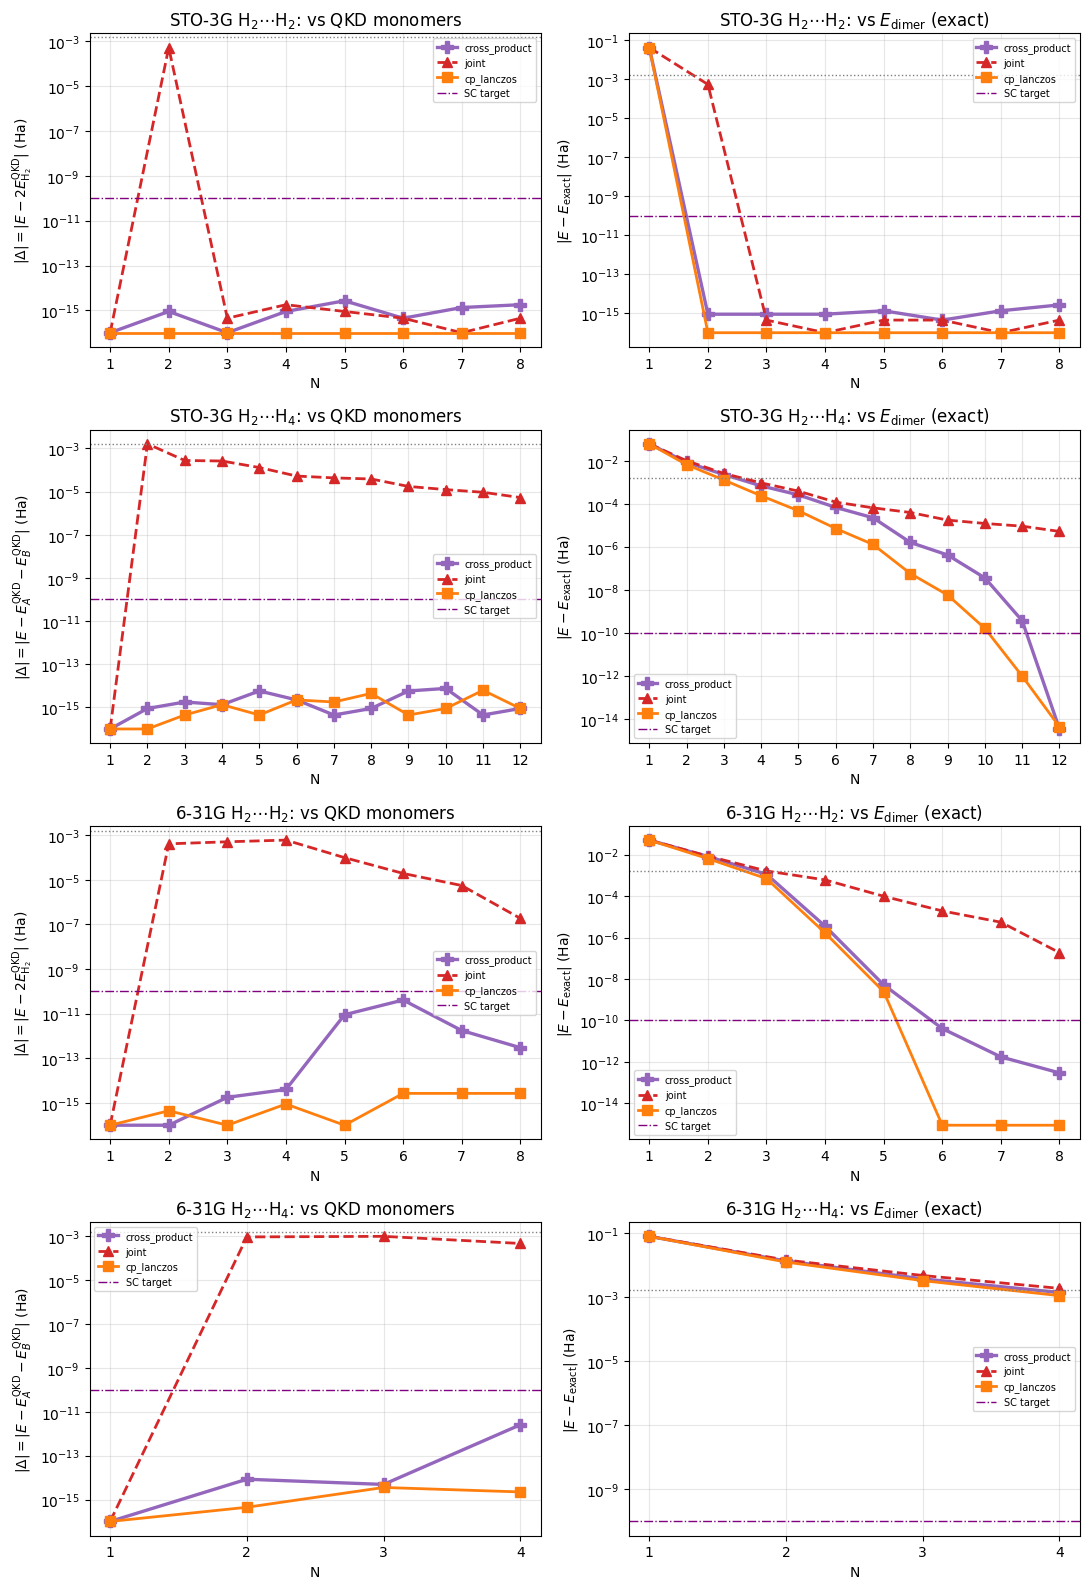

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/sc_R1000_with_lanczos__spectral_norm.png


In [18]:
# §10 SC plots (mirror §8b/9b) with lanczos
n_basis = len(SC_BASIS_LIST)
fig, axes = plt.subplots(n_basis * 2, 2, figsize=(11, 4.0 * n_basis * 2))
if n_basis == 1:
    axes = np.array([axes])

panel = [
    ('H2+H2', r'H$_2\cdots$H$_2$',
     r'$|\Delta|=|E-2E_{\mathrm{H_2}}^{\mathrm{QKD}}|$'),
    ('H2+H4', r'H$_2\cdots$H$_4$',
     r'$|\Delta|=|E-E_A^{\mathrm{QKD}}-E_B^{\mathrm{QKD}}|$'),
]
for b_idx, basis in enumerate(SC_BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    for s_idx, (system, sys_label, ylab) in enumerate(panel):
        row = b_idx * 2 + s_idx
        sub_sys = df_sc_lanczos[
            (df_sc_lanczos['system'] == system) & (df_sc_lanczos['basis'] == basis)
        ]
        for col, (key, title_ref) in enumerate([
            ('abs_vs_mono', 'QKD monomers'),
            ('abs_vs_dimer1000', r'$E_{\mathrm{dimer}}$ (exact)'),
        ]):
            ax = axes[row, col]
            for name in LANCZOS_VARIANTS:
                s = sub_sys[sub_sys['variant'] == name]
                if len(s) == 0:
                    continue
                st = VARIANT_STYLE[name]
                ax.semilogy(s['N'], np.maximum(s[key], 1e-16),
                            color=st['color'], marker=st['marker'], ls=st['ls'],
                            lw=st['lw'], ms=st['ms'], label=name)
            ax.axhline(CHEM_ACC, color='gray', ls=':', lw=1)
            ax.axhline(SC_ASSERT, color='purple', ls='-.', lw=1, label='SC target')
            ax.set_xlabel('N')
            ax.set_ylabel((ylab if col == 0 else r'$|E-E_{\mathrm{exact}}|$') + ' (Ha)')
            ax.set_title(rf'{label} {sys_label}: vs {title_ref}')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3, which='both')
            if len(sub_sys):
                ax.set_xticks(sorted(sub_sys['N'].unique()))
fig.tight_layout()
path = artifact_path('sc_R1000_with_lanczos.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


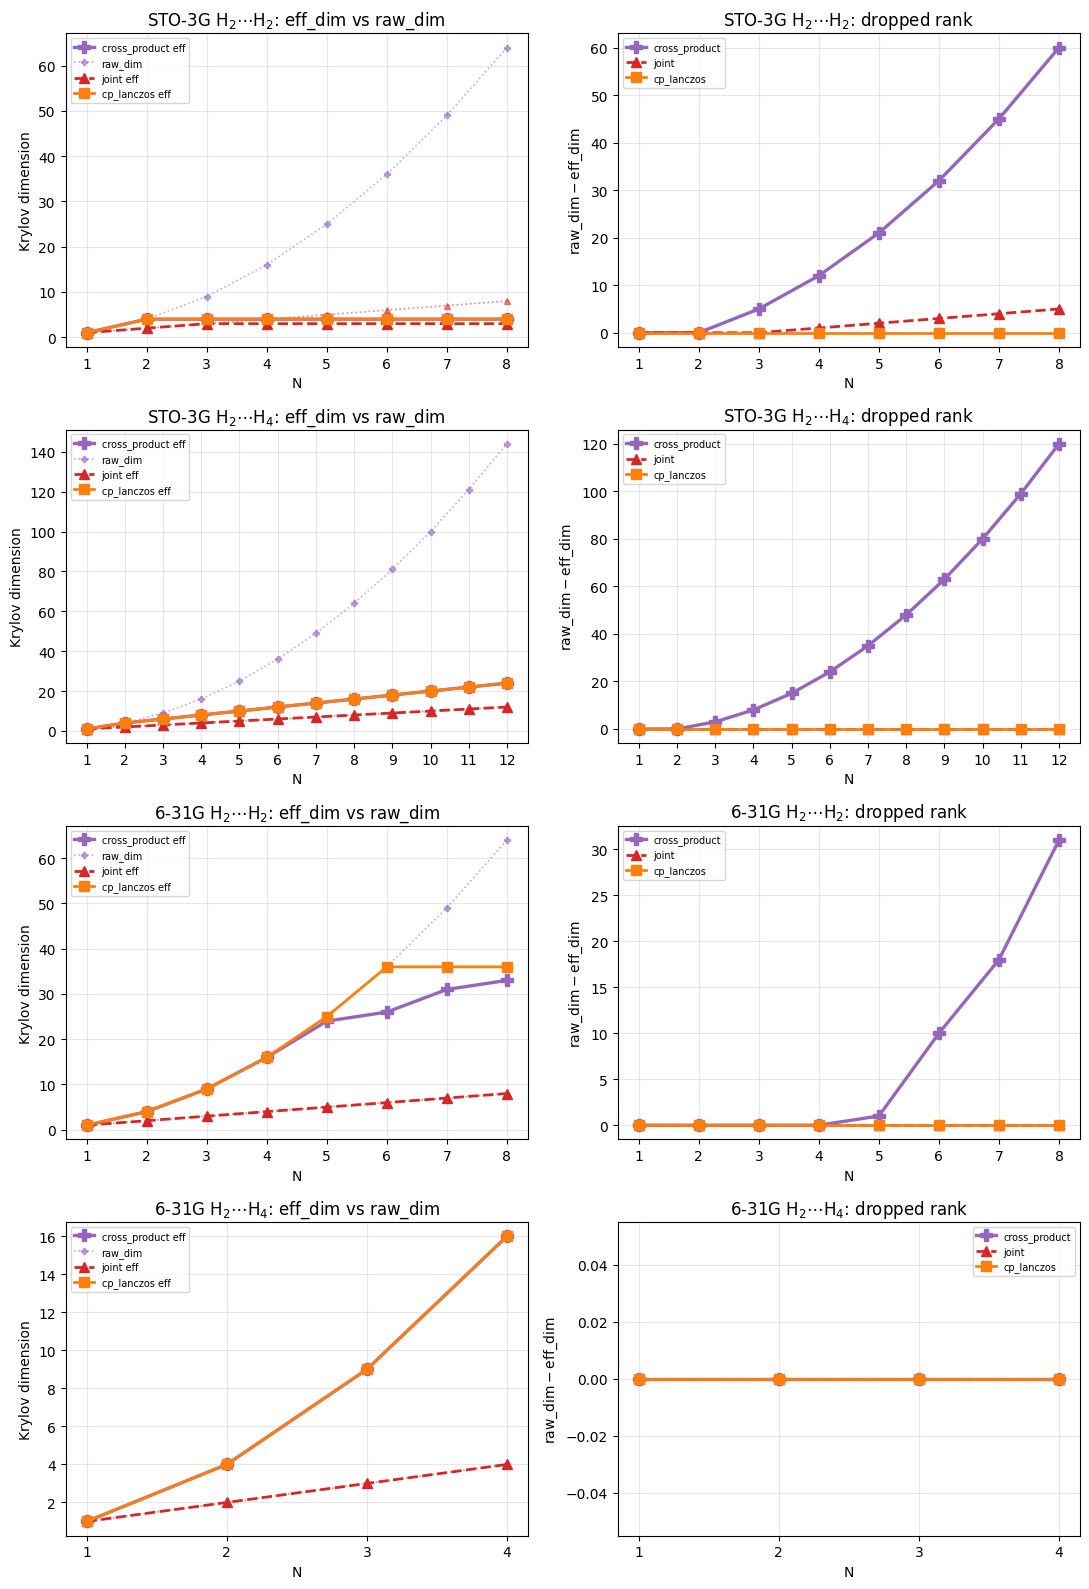

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/sc_effdim_with_lanczos__spectral_norm.png


In [19]:
# §10 rank diagnostic (mirror §8c) with lanczos
n_basis = len(SC_BASIS_LIST)
fig, axes = plt.subplots(n_basis * 2, 2, figsize=(11, 4.0 * n_basis * 2))
if n_basis == 1:
    axes = np.array([axes])

panel = [
    ('H2+H2', r'H$_2\cdots$H$_2$'),
    ('H2+H4', r'H$_2\cdots$H$_4$'),
]
for b_idx, basis in enumerate(SC_BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    for s_idx, (system, sys_label) in enumerate(panel):
        row = b_idx * 2 + s_idx
        sub_sys = df_sc_lanczos[
            (df_sc_lanczos['system'] == system) & (df_sc_lanczos['basis'] == basis)
        ]

        ax = axes[row, 0]
        raw_drawn = False
        for name in LANCZOS_VARIANTS:
            s = sub_sys[sub_sys['variant'] == name].sort_values('N')
            if len(s) == 0:
                continue
            st = VARIANT_STYLE[name]
            ax.plot(s['N'], s['eff_dim'],
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=f'{name} eff')
            ax.plot(s['N'], s['raw_dim'],
                    color=st['color'], marker=st['marker'], ls=':',
                    lw=1.2, ms=5, alpha=0.55,
                    label=('raw_dim' if not raw_drawn else None))
            raw_drawn = True
        ax.set_xlabel('N')
        ax.set_ylabel('Krylov dimension')
        ax.set_title(rf'{label} {sys_label}: eff_dim vs raw_dim')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        if len(sub_sys):
            ax.set_xticks(sorted(sub_sys['N'].unique()))

        ax = axes[row, 1]
        for name in LANCZOS_VARIANTS:
            s = sub_sys[sub_sys['variant'] == name].sort_values('N')
            if len(s) == 0:
                continue
            st = VARIANT_STYLE[name]
            ax.plot(s['N'], s['dropped'],
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
        ax.set_xlabel('N')
        ax.set_ylabel(r'$\mathrm{raw\_dim}-\mathrm{eff\_dim}$')
        ax.set_title(rf'{label} {sys_label}: dropped rank')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        if len(sub_sys):
            ax.set_xticks(sorted(sub_sys['N'].unique()))

fig.tight_layout()
path = artifact_path('sc_effdim_with_lanczos.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)
